# LESSON 21 
# Извлечение данных из веб-страницы

## Примеры урока

In [1]:
import requests

url = 'https://www.labirint.ru/'

response = requests.get(url)
response.status_code, response

(200, <Response [200]>)

In [2]:
response.text # текст HTML-страницы 
# text is the content of the response in Unicode

'<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">\n<html xmlns="http://www.w3.org/1999/xhtml" xmlns:og="http://ogp.me/ns#" xmlns:fb="http://www.facebook.com/2008/fbml" prefix="ya: http://webmaster.yandex.ru/vocabularies/">\n<head>\n<script>\nif(typeof console === \'undefined\') {\n\tvar console = {\n\t\ttime: function (a,b) {},\n\t\ttimeLog: function (a,b) {}\n\t};\n}\nif(!(\'time\' in console)) {\n\tconsole.time = function (a,b) {};\n}\nif(!(\'timeLog\' in console)) {\n\tconsole.timeLog = function (a,b) {};\n}\nconsole.time(\'cart\', \'start\');\nwindow.surfNewDesign = Object.freeze({"is_prod_new_design_product":false,"is_prod_new_design_cart":true,"is_prod_new_design_order_flow":true,"is_prod_new_design_payment":true});\n</script>\n<meta http-equiv="x-dns-prefetch-control" content="on" />\n<meta name="viewport" content="width=device-width, initial-scale=1">\n<link rel="dns-prefetch" href="https://css2.labirint.r

In [3]:
response.content
# content is the content of the response in bytes

b'<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">\n<html xmlns="http://www.w3.org/1999/xhtml" xmlns:og="http://ogp.me/ns#" xmlns:fb="http://www.facebook.com/2008/fbml" prefix="ya: http://webmaster.yandex.ru/vocabularies/">\n<head>\n<script>\nif(typeof console === \'undefined\') {\n\tvar console = {\n\t\ttime: function (a,b) {},\n\t\ttimeLog: function (a,b) {}\n\t};\n}\nif(!(\'time\' in console)) {\n\tconsole.time = function (a,b) {};\n}\nif(!(\'timeLog\' in console)) {\n\tconsole.timeLog = function (a,b) {};\n}\nconsole.time(\'cart\', \'start\');\nwindow.surfNewDesign = Object.freeze({"is_prod_new_design_product":false,"is_prod_new_design_cart":true,"is_prod_new_design_order_flow":true,"is_prod_new_design_payment":true});\n</script>\n<meta http-equiv="x-dns-prefetch-control" content="on" />\n<meta name="viewport" content="width=device-width, initial-scale=1">\n<link rel="dns-prefetch" href="https://css2.labirint.

In [ ]:
# img_url = 'https://lookw.ru/8/828/1476173404-1.jpg'
# img_url = 'https://avatars.mds.yandex.net/i?id=f1360a7072ca68e75052b4a7db2ad92e-4372093-images-thumbs&n=13'

# img_url = 'https://httpbin.org/image/jpeg'  # Тестовое изображение



================ДОПОЛНЕНИЕ========================

In [4]:
import requests
from PIL import Image
import os
import io

os.makedirs('data', exist_ok=True)

# Рабочие URL для России (проверены)
working_urls = [
    'https://httpbin.org/image/jpeg',  # Тестовое изображение
    'https://httpbin.org/image/png',   # Тестовое PNG
    'https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400',  # Unsplash
    'https://raw.githubusercontent.com/python/peps/master/pep-0000/pep-0000.png',  # Python logo
]

for url in working_urls:
    print(f"\nПробуем: {url}")
    try:
        response = requests.get(url, timeout=10)
        print(f"  Статус: {response.status_code}")
        print(f"  Размер: {len(response.content)} байт")
        print(f"  Content-Type: {response.headers.get('content-type')}")
        
        if response.status_code == 200 and len(response.content) > 1000:
            file_name = f'data/test_image_{working_urls.index(url)}.jpg'
            with open(file_name, 'wb') as f:
                f.write(response.content)
            
            # Проверяем сигнатуру JPEG
            with open(file_name, 'rb') as f:
                header = f.read(2)
                if header.hex() == 'ffd8':
                    print(f"  ✅ JPEG найден!")
                    img = Image.open(file_name)
                    print(f"  ✅ Изображение открыто! Размер: {img.size}")
                    img.show()
                    break
                else:
                    print(f"  Сигнатура: {header.hex()}")
                    
    except Exception as e:
        print(f"  Ошибка: {e}")


Пробуем: https://httpbin.org/image/jpeg
  Ошибка: HTTPSConnectionPool(host='httpbin.org', port=443): Read timed out. (read timeout=10)

Пробуем: https://httpbin.org/image/png
  Статус: 200
  Размер: 8090 байт
  Content-Type: image/png
  Сигнатура: 8950

Пробуем: https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400
  Ошибка: HTTPSConnectionPool(host='images.unsplash.com', port=443): Read timed out. (read timeout=10)

Пробуем: https://raw.githubusercontent.com/python/peps/master/pep-0000/pep-0000.png
  Статус: 404
  Размер: 14 байт
  Content-Type: text/plain; charset=utf-8


In [5]:
import requests
from PIL import Image
import os

def download_and_show_image(url, file_name='data/image1.jpg'):
    """Универсальная функция для скачивания и показа изображений"""
    
    # Создаем папку data
    os.makedirs('data', exist_ok=True)
    
    # Добавляем заголовки для обхода блокировок
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    
    try:
        # Скачиваем
        response = requests.get(url, headers=headers, timeout=10)
        
        # Проверяем успешность
        if response.status_code != 200:
            print(f"❌ Ошибка HTTP: {response.status_code}")
            return False
        
        # Проверяем, что это изображение (простая проверка)
        if len(response.content) < 1000:
            print(f"❌ Файл слишком маленький ({len(response.content)} байт)")
            return False
        
        # Сохраняем
        with open(file_name, 'wb') as f:
            f.write(response.content)
        print(f"✅ Сохранено {len(response.content)} байт в {file_name}")
        
        # Открываем и показываем
        img = Image.open(file_name)
        print(f"✅ Изображение {img.size[0]}x{img.size[1]} пикселей")
        img.show()
        return True
        
    except Exception as e:
        print(f"❌ Ошибка: {e}")
        return False

# Пример использования
# url = 'https://httpbin.org/image/jpeg'  # Рабочий URL
# url = 'https://books.toscrape.com/media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg'
# sample_images = [
#     "https://yavuzceliker.github.io/sample-images/image-1.jpg",
#     "https://yavuzceliker.github.io/sample-images/image-100.jpg",
#     "https://yavuzceliker.github.io/sample-images/image-1021.jpg",
#     "https://yavuzceliker.github.io/sample-images/image-2000.jpg",
# ]

# url = 'https://upload.wikimedia.org/wikipedia/commons/7/73/Lion_waiting_in_Namibia.jpg'   #"Лев"
# url = 'https://upload.wikimedia.org/wikipedia/commons/0/0f/Grosser_Panda.JPG'               # "Панда"
url = 'https://upload.wikimedia.org/wikipedia/commons/e/ec/Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg'          # "Земля"
download_and_show_image(url)

✅ Сохранено 94310471 байт в data/image1.jpg
✅ Изображение 7479x11146 пикселей


True

In [6]:
url = "https://www.python.org/static/img/python-logo.png"
download_and_show_image(url)

✅ Сохранено 15770 байт в data/image1.jpg
✅ Изображение 580x164 пикселей


True

✅ Полный рабочий пример

In [7]:
import requests
from PIL import Image
import os

# Создаем папку data
os.makedirs('data', exist_ok=True)

# URL изображения (например, с Wikimedia)
url = 'https://upload.wikimedia.org/wikipedia/commons/7/73/Lion_waiting_in_Namibia.jpg'

# Заголовки как у браузера
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

# Скачиваем с заголовками
print("Скачиваем изображение...")
response = requests.get(url, headers=headers)

# Проверяем результат
if response.status_code == 200:
    print(f"✅ Успешно! Статус: {response.status_code}")
    print(f"✅ Размер: {len(response.content)} байт")
    print(f"✅ Content-Type: {response.headers.get('content-type')}")
    
    # Сохраняем
    file_name = 'data/lion_with_headers.jpg'
    with open(file_name, 'wb') as f:
        f.write(response.content)
    print(f"✅ Сохранено в {file_name}")
    
    # Открываем и показываем
    img = Image.open(file_name)
    print(f"✅ Изображение открыто! Размер: {img.size[0]}x{img.size[1]} пикселей")
    img.show()
else:
    print(f"❌ Ошибка: {response.status_code}")

Скачиваем изображение...
✅ Успешно! Статус: 200
✅ Размер: 314509 байт
✅ Content-Type: image/jpeg
✅ Сохранено в data/lion_with_headers.jpg
✅ Изображение открыто! Размер: 1280x960 пикселей


🔄 Функция для повторного использования

In [8]:
import requests
from PIL import Image
import os

def download_image_with_headers(url, filename='data/image.jpg'):
    """Скачивает изображение с использованием User-Agent заголовка"""
    
    os.makedirs('data', exist_ok=True)
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        
        if response.status_code != 200:
            print(f"❌ HTTP ошибка: {response.status_code}")
            return False
        
        if len(response.content) < 1000:
            print(f"❌ Файл слишком маленький: {len(response.content)} байт")
            return False
        
        # Сохраняем
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"✅ Сохранено: {filename} ({len(response.content)} байт)")
        
        # Открываем и показываем
        img = Image.open(filename)
        print(f"✅ Размер изображения: {img.size[0]}x{img.size[1]} пикселей")
        img.show()
        return True
        
    except Exception as e:
        print(f"❌ Ошибка: {e}")
        return False

# Пример использования с разными URL
urls = [
    'https://upload.wikimedia.org/wikipedia/commons/0/0f/Grosser_Panda.JPG',
    'https://httpbin.org/image/jpeg',
    'https://yavuzceliker.github.io/sample-images/image-42.jpg',
]

for i, url in enumerate(urls):
    print(f"\n--- Загрузка {i+1} ---")
    download_image_with_headers(url, f'data/test_image_{i+1}.jpg')


--- Загрузка 1 ---
✅ Сохранено: data/test_image_1.jpg (5012179 байт)
✅ Размер изображения: 4272x2848 пикселей

--- Загрузка 2 ---
✅ Сохранено: data/test_image_2.jpg (35588 байт)
✅ Размер изображения: 239x178 пикселей

--- Загрузка 3 ---
✅ Сохранено: data/test_image_3.jpg (86691 байт)
✅ Размер изображения: 854x1280 пикселей


🎯 Реальный пример: скачивание с защищенного сайта

In [9]:
import requests
from PIL import Image
import os

# Пример сайта, который может блокировать запросы без заголовков
# (хотя этот конкретный URL может работать и без них)

url = 'https://www.python.org/static/img/python-logo.png'

# Расширенные заголовки (как у реального браузера)
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'image/webp,image/apng,image/svg+xml,image/*,*/*;q=0.8',
    'Accept-Language': 'ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7',
    'Cache-Control': 'no-cache',
}

print("Скачиваем логотип Python...")
response = requests.get(url, headers=headers)

if response.status_code == 200:
    os.makedirs('data', exist_ok=True)
    file_name = 'data/python_logo.png'
    
    with open(file_name, 'wb') as f:
        f.write(response.content)
    
    print(f"✅ Сохранено! Размер: {len(response.content)} байт")
    
    # Открываем PNG
    img = Image.open(file_name)
    print(f"✅ Изображение: {img.size[0]}x{img.size[1]} пикселей, формат: {img.format}")
    img.show()
else:
    print(f"❌ Ошибка: {response.status_code}")

Скачиваем логотип Python...
✅ Сохранено! Размер: 15770 байт
✅ Изображение: 580x164 пикселей, формат: PNG


📌 Универсальный шаблон

In [10]:
def smart_download(url, filename='data/image.jpg'):
    """Умное скачивание с автоматическими заголовками"""
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    
    try:
        # Сначала пробуем с заголовками
        response = requests.get(url, headers=headers, timeout=10)
        
        # Если не помогло, пробуем без
        if response.status_code == 403:
            print("Пробуем без заголовков...")
            response = requests.get(url, timeout=10)
        
        if response.status_code == 200 and len(response.content) > 1000:
            os.makedirs(os.path.dirname(filename), exist_ok=True)
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f"✅ Успешно: {filename}")
            return Image.open(filename)
        else:
            print(f"❌ Не удалось: статус {response.status_code}")
            return None
            
    except Exception as e:
        print(f"❌ Ошибка: {e}")
        return None

✅ Успешно: data/image.jpg


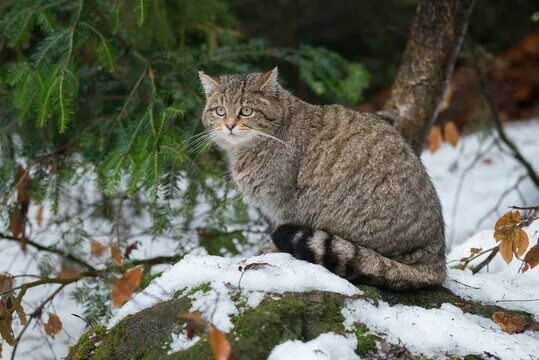

In [11]:
url = 'https://avatars.mds.yandex.net/i?id=0ed3a4c683b451cf81ac9ca335d063f7_l-8497596-images-thumbs&n=13'


smart_download(url, filename='data/image.jpg')

================ДОПОЛНЕНИЕ(end)========================

In [12]:
img_url = 'https://avatars.mds.yandex.net/i?id=0ed3a4c683b451cf81ac9ca335d063f7_l-8497596-images-thumbs&n=13'
# картинка скачивается  как бинарный файл, в рисунок не преобразуется,
image = requests.get(img_url)
file_name = 'data/image1.jpg'
with open(file_name, 'wb') as f: # для сохранения картинки используется image.content
  f.write(image.content)

In [13]:
get_params = {'q': 'cat'}
response = requests.get('https://www.google.com/search', params=get_params)
response.url

'https://www.google.com/search?q=cat'

***Поисковый запрос в Yandex***

In [14]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(response.text, "html.parser")

# получить все теги img с параметром alass_ = "serp-item__thumb justifier__thumb"
imgs = soup.body.findAll("img", class_="serp-item__thumb justifier__thumb")

imgs

C:\Users\master\AppData\Local\Temp\ipykernel_17304\1445686919.py:5: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  imgs = soup.body.findAll("img", class_="serp-item__thumb justifier__thumb")


[]

In [15]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

# Получаем все теги img с нужным классом (используем find_all)
imgs = soup.body.find_all("img", class_="serp-item__thumb justifier__thumb")
imgs

[]

In [16]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

# 1. Проверяем, существует ли body
if soup.body:
    print("✅ Body найден")
else:
    print("❌ Body не найден")
    print("Возможно, страница не содержит тег body или response.text пустой")

# 2. Смотрим все img на странице
all_imgs = soup.find_all("img")
print(f"\nВсего img тегов на странице: {len(all_imgs)}")

if len(all_imgs) > 0:
    print("\nПервые 5 img и их классы:")
    for i, img in enumerate(all_imgs[:5]):
        print(f"{i+1}. src: {img.get('src', 'нет src')}")
        print(f"   class: {img.get('class', 'нет класса')}")
        print(f"   id: {img.get('id', 'нет id')}")
        print()

# 3. Ищем img с любым классом, содержащим serp-item
serp_images = soup.find_all("img", class_=lambda c: c and "serp-item" in str(c))
print(f"Найдено img с 'serp-item' в классе: {len(serp_images)}")

# 4. Ищем ВСЕ элементы с нужными классами (не только img)
elements = soup.find_all(class_="serp-item__thumb")
print(f"Элементов с классом 'serp-item__thumb': {len(elements)}")

# 5. Проверяем, может быть классы в другом атрибуте
if len(elements) == 0:
    # Ищем частичное совпадение
    all_with_serp = soup.find_all(class_=lambda c: c and "serp" in str(c).lower())
    print(f"Элементов, содержащих 'serp' в классе: {len(all_with_serp)}")
    
    if len(all_with_serp) > 0:
        print("Примеры классов:", [elem.get('class') for elem in all_with_serp[:3]])

# 6. Проверяем, не динамическая ли страница
if len(all_imgs) == 0 and len(response.text) > 1000:
    print("\n⚠️ На странице нет img тегов, но есть текст.")
    print("Возможно, изображения подгружаются через JavaScript.")
    print("Попробуйте использовать Selenium или посмотрите первые 500 символов:")
    print(response.text[:500])

✅ Body найден

Всего img тегов на странице: 0
Найдено img с 'serp-item' в классе: 0
Элементов с классом 'serp-item__thumb': 0
Элементов, содержащих 'serp' в классе: 0

⚠️ На странице нет img тегов, но есть текст.
Возможно, изображения подгружаются через JavaScript.
Попробуйте использовать Selenium или посмотрите первые 500 символов:
<!DOCTYPE html><html lang="ru"><head><title>Google Search</title><style>body{background-color:#fff}</style><script nonce="Fx4lyWsDdofWhigSsDi1QA">window.google = window.google || {};window.google.c = window.google.c || {cap:0};</script></head><body><noscript><style>table,div,span,p{display:none}</style><meta content="0;url=/httpservice/retry/enablejs?sei=7Ez4aa_KFL7FwPAP-JGSyQg" http-equiv="refresh"><div style="display:block">&#1053;&#1072;&#1078;&#1084;&#1080;&#1090;&#1077; <a href="/httpservic


In [17]:
import requests
from bs4 import BeautifulSoup
import time

def get_bing_images(query, num_images=10):
    """Получает URL изображений из Bing"""
    
    url = f"https://www.bing.com/images/search?q={query}"
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    images = []
    for img in soup.find_all('img', class_='mimg'):
        src = img.get('src')
        if src and src.startswith('http'):
            images.append(src)
        if len(images) >= num_images:
            break
    
    return images

# Использование
images = get_bing_images("лошади", 5)
for i, img_url in enumerate(images):
    print(f"{i+1}. {img_url}")

1. https://tse3.mm.bing.net/th/id/OIP.nK9eiT9yg9OUKyySvdTR2AHaJ4?w=148&h=197&c=7&r=0&o=5&pid=1.7
2. https://tse4.mm.bing.net/th/id/OIP.gvohFE5SkKH9fiXZxlIoFAHaG9?w=209&h=197&c=7&r=0&o=5&pid=1.7
3. https://tse1.mm.bing.net/th/id/OIP.i2VjjXvhOLCPZ9YY6GIiCgHaE7?w=296&h=197&c=7&r=0&o=5&pid=1.7
4. https://tse1.mm.bing.net/th/id/OIP._Ibv48bCvNyGdiCB-7NIdQHaFj?w=261&h=197&c=7&r=0&o=5&pid=1.7
5. https://tse4.mm.bing.net/th/id/OIP.L8F52rSuXG8G47GrA9ZzJwHaFh?w=253&h=188&c=7&r=0&o=5&pid=1.7


In [18]:
import requests
from bs4 import BeautifulSoup
import json
import re

def parse_yandex_images(query, limit=30):
    """Парсинг Яндекс.Картинок и получение списка img тегов"""
    
    # Формируем URL для поиска
    url = f"https://yandex.ru/images/search?text={query}"
    
    # Заголовки как у браузера (важно для Яндекса!)
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
        'Accept-Language': 'ru-RU,ru;q=0.8,en-US;q=0.5,en;q=0.3',
    }
    
    # Отправляем запрос
    response = requests.get(url, headers=headers)
    print(f"Статус: {response.status_code}")
    
    # Создаем суп
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Способ 1: Прямой поиск img с нужными классами (как в вашем выводе)
    imgs = soup.find_all('img', class_='serp-item__thumb')
    
    if not imgs:
        # Способ 2: Поиск через общий класс
        imgs = soup.find_all('img', class_=re.compile(r'serp-item__thumb'))
    
    if not imgs:
        # Способ 3: Поиск всех img с data-src (Яндекс часто использует)
        imgs = soup.find_all('img', attrs={'data-src': re.compile(r'.*')})
    
    # Ограничиваем количество
    imgs = imgs[:limit]
    
    print(f"Найдено изображений: {len(imgs)}")
    return imgs

# Использование
query = "котики"
images = parse_yandex_images(query)

# Выводим результат как в вашем примере
for img in images:
    print(img)

Статус: 200
Найдено изображений: 0


К сожалению, использование только библиотек requests и BeautifulSoup здесь не поможет. Ваш код верен, но вы столкнулись с главной технической проблемой: Яндекс, как и Google, загружает изображения динамически через JavaScript. Простой HTTP-запрос возвращает только пустую оболочку страницы.

🛠️ Вариант 1. Использовать ddgs (самый простой)

In [19]:
# Установка: pip install ddgs

from ddgs import DDGS

def get_images_with_ddgs(query, max_results=30):
    """Получает изображения через библиотеку ddgs"""
    with DDGS() as ddgs:
        # Функция ddgs.images() возвращает генератор с результатами
        results = ddgs.images(query, max_results=max_results)
        
        image_list = []
        for result in results:
            # Каждый результат — это словарь с информацией об изображении
            image_list.append({
                'title': result.get('title'),
                'image_url': result.get('image'),
                'source_url': result.get('url'),
                'width': result.get('width'),
                'height': result.get('height')
            })
        return image_list

# Получаем 30 картинок с котиками
images = get_images_with_ddgs("кот", max_results=30)

# Выводим результат
for i, img in enumerate(images):
    print(f"{i+1}. URL: {img['image_url']}")
    print(f"   Название: {img['title'][:50]}")
    print('---')

1. URL: https://placepic.ru/wp-content/uploads/2018/11/c24f98eba82666ae547b138be9933bd1.jpg
   Название: Котята разных пород (65 фото) Фотографии милых кот
---
2. URL: https://www.sunny-cat.ru/datas/users/1-garik028.jpg
   Название: Породы кошек с 13696 фото и названиями, 805 кошек 
---
3. URL: https://wide-w.com/wp-content/uploads/2018/08/shotlandskij-vislouhij-kot-1920x1080.jpg
   Название: Шотландский вислоухий кот HD (2560×1440) – Вислоух
---
4. URL: https://kr-gazeta.ru/upload/iblock/dfa/samyy_krasivyy_kot_v_mire_rodilsya_v_pitomnike_urozhenki_chelyabinska.jpg
   Название: Самый красивый кот в мире родился в питомнике урож
---
5. URL: https://klike.net/uploads/posts/2020-03/1583662555_17.jpg
   Название: Красивые картинки котов - 93+ фото
---
6. URL: https://heaclub.ru/tim/6d02b8d5af0d98557ee0f5b38f275b6d/britanskie-korotkosherstnie.jpg
   Название: Все породы домашних кошек и котов с фотографиями и
---
7. URL: https://edyal.ru/800/600/https/img-fotki.yandex.ru/get/227342/27433797

🕸️ Вариант 2. Использовать Selenium (имитация браузера)

In [20]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
import time

def get_yandex_images_selenium(query, limit=10):
    """Получает изображения с Яндекс.Картинок через Selenium (обновленная версия)"""
    
    # Настройки браузера для обхода блокировки
    options = Options()
    options.add_argument('--disable-blink-features=AutomationControlled')
    options.add_argument('--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)
    
    driver = webdriver.Chrome(options=options)
    driver.execute_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")
    
    try:
        # Открываем страницу
        url = f"https://yandex.ru/images/search?text={query}"
        print(f"Открываем: {url}")
        driver.get(url)
        
        # Ждем загрузки страницы (более гибкий подход)
        time.sleep(5)
        
        # Пробуем разные варианты селекторов
        selectors = [
            "img.serp-item__thumb",
            ".serp-item__thumb img",
            "[class*='serp-item'] img",
            "img[data-src]",
            ".ImagesViewer-Tile-Image",
            "img[alt]"
        ]
        
        img_elements = []
        for selector in selectors:
            try:
                elements = WebDriverWait(driver, 5).until(
                    EC.presence_of_all_elements_located((By.CSS_SELECTOR, selector))
                )
                if elements:
                    img_elements = elements
                    print(f"✅ Найдено по селектору: {selector}")
                    break
            except:
                continue
        
        if not img_elements:
            # Если не нашли, ищем все img
            img_elements = driver.find_elements(By.TAG_NAME, "img")
            print(f"Найдено всех img: {len(img_elements)}")
        
        # Скроллим для загрузки
        for i in range(3):
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(2)
        
        # Собираем результаты
        results = []
        for img in img_elements[:limit]:
            try:
                # Пробуем получить src из разных атрибутов
                src = (img.get_attribute('src') or 
                      img.get_attribute('data-src') or 
                      img.get_attribute('data-url') or 
                      img.get_attribute('origin') or 
                      'src не найден')
                
                # Фильтруем пустые и data:image
                if src and not src.startswith('data:image') and len(src) > 10:
                    results.append({
                        'src': src,
                        'alt': img.get_attribute('alt') or 'без описания',
                        'class': img.get_attribute('class')
                    })
            except:
                continue
        
        return results
        
    except Exception as e:
        print(f"Ошибка: {e}")
        return []
    finally:
        driver.quit()

# Использование
print("Начинаем парсинг...")
images = get_yandex_images_selenium("котики", limit=10)

print(f"\n{'='*60}")
print(f"Найдено {len(images)} изображений")
print(f"{'='*60}\n")

for i, img in enumerate(images, 1):
    print(f"{i}. URL: {img['src'][:100]}")
    print(f"   Alt: {img['alt'][:50]}")
    print()

Начинаем парсинг...
Открываем: https://yandex.ru/images/search?text=котики
✅ Найдено по селектору: img[alt]

Найдено 10 изображений

1. URL: https://avatars.mds.yandex.net/i?id=7f18c7f70789c324859f7036c1ab0e49ea1a6e94-5505402-images-thumbs&n
   Alt: Ultimate Cat Cuteness Overload 😸 Cute Kittens Play

2. URL: https://avatars.mds.yandex.net/i?id=62a46934ce04a4ab3a1f4bda9dcef16019b11a84-5449727-images-thumbs&n
   Alt: Page 2 Cheerful Cat Images - Free Download on Free

3. URL: https://avatars.mds.yandex.net/i?id=d198a39566b6de9a72b3122384f0b98ecc636821-6450036-images-thumbs&n
   Alt: Картинки кошек на аватарку

4. URL: https://avatars.mds.yandex.net/i?id=5230bd68a108e2faf1257f81c3bb44cab466a91b-4958646-images-thumbs&n
   Alt: Cat Memes Hub - YouTube

5. URL: https://avatars.mds.yandex.net/i?id=4567a400a4d0d3785722e6ac0c1337067adaadc8-8000127-images-thumbs&n
   Alt: Страница 3 Funny kitten Изображения - скачать бесп

6. URL: https://avatars.mds.yandex.net/i?id=3da71449e45daf025bdd6145906da

In [21]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
import requests
import os
import time

def get_yandex_images(query, limit=10):
    """Получает изображения с Яндекс.Картинок"""
    
    options = Options()
    options.add_argument('--disable-blink-features=AutomationControlled')
    options.add_argument('--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')
    
    driver = webdriver.Chrome(options=options)
    
    try:
        url = f"https://yandex.ru/images/search?text={query}"
        driver.get(url)
        time.sleep(3)
        
        # Поиск изображений
        img_elements = driver.find_elements(By.CSS_SELECTOR, "img[alt]")
        
        results = []
        for img in img_elements[:limit]:
            src = img.get_attribute('src') or img.get_attribute('data-src')
            if src and not src.startswith('data:'):
                results.append({
                    'src': src,
                    'alt': img.get_attribute('alt') or 'без описания'
                })
        
        return results
        
    finally:
        driver.quit()

def download_images(images, folder='cats'):
    """Скачивает изображения"""
    os.makedirs(folder, exist_ok=True)
    
    for i, img in enumerate(images, 1):
        try:
            url = img['src']
            if url.startswith('//'):
                url = 'https:' + url
            
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                filename = os.path.join(folder, f'{i}.jpg')
                with open(filename, 'wb') as f:
                    f.write(response.content)
                print(f"✅ {i}. {filename}")
            else:
                print(f"❌ {i}. Ошибка {response.status_code}")
        except Exception as e:
            print(f"❌ {i}. {e}")

# Запуск
print("🔍 Поиск изображений...")
images = get_yandex_images("милые котики", limit=10)

print(f"\n📸 Найдено {len(images)} изображений")
print("\n💾 Скачивание...")
download_images(images)

print("\n✨ Готово! Изображения сохранены в папке 'cats'")

🔍 Поиск изображений...

📸 Найдено 10 изображений

💾 Скачивание...
✅ 1. cats\1.jpg
✅ 2. cats\2.jpg
✅ 3. cats\3.jpg
✅ 4. cats\4.jpg
✅ 5. cats\5.jpg
✅ 6. cats\6.jpg
✅ 7. cats\7.jpg
✅ 8. cats\8.jpg
✅ 9. cats\9.jpg
✅ 10. cats\10.jpg

✨ Готово! Изображения сохранены в папке 'cats'


In [22]:
html_doc = """
<html>
 <head>
  <meta http-equiv="Content-Type" content="text/html; charset=utf-8">
  <title>Пример</title>
 </head>
 <body>
  <h1>Самый большой заголовок</h1>
  <p class="title page" align="center">Первый абзац</p>
  <p class = 's' >Второй абзац</p>
  <p class="title page s">Третий абзац</p>
  <ul class="s">
    <li>Первый пункт</li>
    <li>Второй пункт</li>
    <li>Третий пункт</li>
  </ul>
  <img src="images/picture1.png" width="189" height="255" alt="lorem">
  <p id="link"><a href="/pictures/tip.html">Переход по ссылке</a></p>
  <p id="link2" class="s"><a href="tip2.html">Переход по ссылке2</a></p> 
  <img src="images/picture2.png" width="189" height="255" alt="lorem">
  <ol>
    <li>Первый пункт</li>
    <li>Второй пункт</li>
    <li>Третий пункт</li>
  </ol>
  
 </body>
</html>
"""

In [23]:
import requests
from bs4 import BeautifulSoup
soup = BeautifulSoup(html_doc, 'html.parser')
print(soup.prettify())

<html>
 <head>
  <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
  <title>
   Пример
  </title>
 </head>
 <body>
  <h1>
   Самый большой заголовок
  </h1>
  <p align="center" class="title page">
   Первый абзац
  </p>
  <p class="s">
   Второй абзац
  </p>
  <p class="title page s">
   Третий абзац
  </p>
  <ul class="s">
   <li>
    Первый пункт
   </li>
   <li>
    Второй пункт
   </li>
   <li>
    Третий пункт
   </li>
  </ul>
  <img alt="lorem" height="255" src="images/picture1.png" width="189"/>
  <p id="link">
   <a href="/pictures/tip.html">
    Переход по ссылке
   </a>
  </p>
  <p class="s" id="link2">
   <a href="tip2.html">
    Переход по ссылке2
   </a>
  </p>
  <img alt="lorem" height="255" src="images/picture2.png" width="189"/>
  <ol>
   <li>
    Первый пункт
   </li>
   <li>
    Второй пункт
   </li>
   <li>
    Третий пункт
   </li>
  </ol>
 </body>
</html>



In [24]:
soup.head

<head>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<title>Пример</title>
</head>

In [25]:
soup.body

<body>
<h1>Самый большой заголовок</h1>
<p align="center" class="title page">Первый абзац</p>
<p class="s">Второй абзац</p>
<p class="title page s">Третий абзац</p>
<ul class="s">
<li>Первый пункт</li>
<li>Второй пункт</li>
<li>Третий пункт</li>
</ul>
<img alt="lorem" height="255" src="images/picture1.png" width="189"/>
<p id="link"><a href="/pictures/tip.html">Переход по ссылке</a></p>
<p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>
<img alt="lorem" height="255" src="images/picture2.png" width="189"/>
<ol>
<li>Первый пункт</li>
<li>Второй пункт</li>
<li>Третий пункт</li>
</ol>
</body>

In [26]:
soup.text

'\n\n\n\nПример\n\n\nСамый большой заголовок\nПервый абзац\nВторой абзац\nТретий абзац\n\nПервый пункт\nВторой пункт\nТретий пункт\n\n\nПереход по ссылке\nПереход по ссылке2\n\n\nПервый пункт\nВторой пункт\nТретий пункт\n\n\n\n'

In [27]:
soup.get_text()

'\n\n\n\nПример\n\n\nСамый большой заголовок\nПервый абзац\nВторой абзац\nТретий абзац\n\nПервый пункт\nВторой пункт\nТретий пункт\n\n\nПереход по ссылке\nПереход по ссылке2\n\n\nПервый пункт\nВторой пункт\nТретий пункт\n\n\n\n'

In [28]:
soup.title

<title>Пример</title>

In [29]:
soup.title, soup.title.text, soup.title.string

(<title>Пример</title>, 'Пример', 'Пример')

In [30]:
soup.title.name, soup.title.parent

('title',
 <head>
 <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
 <title>Пример</title>
 </head>)

In [31]:
list(soup.head.children)

['\n',
 <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>,
 '\n',
 <title>Пример</title>,
 '\n']

In [32]:
list(soup.body.children)

['\n',
 <h1>Самый большой заголовок</h1>,
 '\n',
 <p align="center" class="title page">Первый абзац</p>,
 '\n',
 <p class="s">Второй абзац</p>,
 '\n',
 <p class="title page s">Третий абзац</p>,
 '\n',
 <ul class="s">
 <li>Первый пункт</li>
 <li>Второй пункт</li>
 <li>Третий пункт</li>
 </ul>,
 '\n',
 <img alt="lorem" height="255" src="images/picture1.png" width="189"/>,
 '\n',
 <p id="link"><a href="/pictures/tip.html">Переход по ссылке</a></p>,
 '\n',
 <p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>,
 '\n',
 <img alt="lorem" height="255" src="images/picture2.png" width="189"/>,
 '\n',
 <ol>
 <li>Первый пункт</li>
 <li>Второй пункт</li>
 <li>Третий пункт</li>
 </ol>,
 '\n']

In [33]:
soup.p

<p align="center" class="title page">Первый абзац</p>

In [34]:
soup.find('p')

<p align="center" class="title page">Первый абзац</p>

In [35]:
soup.find_all('p')

[<p align="center" class="title page">Первый абзац</p>,
 <p class="s">Второй абзац</p>,
 <p class="title page s">Третий абзац</p>,
 <p id="link"><a href="/pictures/tip.html">Переход по ссылке</a></p>,
 <p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>]

In [36]:
soup.findAll('p')

C:\Users\master\AppData\Local\Temp\ipykernel_17304\3473612551.py:1: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  soup.findAll('p')


[<p align="center" class="title page">Первый абзац</p>,
 <p class="s">Второй абзац</p>,
 <p class="title page s">Третий абзац</p>,
 <p id="link"><a href="/pictures/tip.html">Переход по ссылке</a></p>,
 <p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>]

In [37]:
soup.find_all('p', class_='page')

[<p align="center" class="title page">Первый абзац</p>,
 <p class="title page s">Третий абзац</p>]

In [38]:
soup.findAll('p', class_='s')

C:\Users\master\AppData\Local\Temp\ipykernel_17304\794987308.py:1: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  soup.findAll('p', class_='s')


[<p class="s">Второй абзац</p>,
 <p class="title page s">Третий абзац</p>,
 <p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>]

In [39]:
for p in soup.find_all('p'):
  if p.has_attr('class'):
    print(p['class'])

['title', 'page']
['s']
['title', 'page', 's']
['s']


In [40]:
soup.find_all('a')

[<a href="/pictures/tip.html">Переход по ссылке</a>,
 <a href="tip2.html">Переход по ссылке2</a>]

In [41]:
soup.find(id="link")

<p id="link"><a href="/pictures/tip.html">Переход по ссылке</a></p>

In [42]:
for p in soup.find_all('p'):
  print(p.get('class'))

['title', 'page']
['s']
['title', 'page', 's']
None
['s']


In [43]:
for link in soup.find_all('a'):
    print(link.get('href'))

/pictures/tip.html
tip2.html


In [44]:
for link in soup.find_all('a'):
    print(link['href'])

/pictures/tip.html
tip2.html


In [45]:
for link in soup.find_all('img'):
    print(link.get('src'))

images/picture1.png
images/picture2.png


In [46]:
for link in soup.find_all('img'):
    print(link['src'])

images/picture1.png
images/picture2.png


In [47]:
def get_src(x):
  return x.get('src')

list(map(get_src,  soup.find_all('img')))

['images/picture1.png', 'images/picture2.png']

In [48]:
[x.get('src') for x in soup.find_all('img')]

['images/picture1.png', 'images/picture2.png']

In [49]:
soup.select('p.page')

[<p align="center" class="title page">Первый абзац</p>,
 <p class="title page s">Третий абзац</p>]

In [50]:
soup.select(".s")

[<p class="s">Второй абзац</p>,
 <p class="title page s">Третий абзац</p>,
 <ul class="s">
 <li>Первый пункт</li>
 <li>Второй пункт</li>
 <li>Третий пункт</li>
 </ul>,
 <p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>]

In [51]:
soup.select('#link')

[<p id="link"><a href="/pictures/tip.html">Переход по ссылке</a></p>]

In [52]:
def get_src(x):
  return x.get('href')

list(map(get_src,  soup.select('a[href="tip2.html"]'))) # равен 

['tip2.html']

In [53]:
def get_src(x):
  return x.get('href')

list(map(get_src,  soup.select('a[href^="/"]'))) # начинается с /

['/pictures/tip.html']

In [54]:
def get_src(x):
  return x.get('src')

list(map(get_src,  soup.select('img[src$="png"]'))) # заканчивается на png


['images/picture1.png', 'images/picture2.png']

In [55]:
def get_src(x):
  return x.get('href')

list(map(get_src, soup.select('a[href*="."]'))) # содержит символ .

['/pictures/tip.html', 'tip2.html']

In [56]:
p = soup.find('p')
p2 = p.find_next()
all = p.find_all_next()
all_p = p.find_all_next('p') 
all_p

[<p class="s">Второй абзац</p>,
 <p class="title page s">Третий абзац</p>,
 <p id="link"><a href="/pictures/tip.html">Переход по ссылке</a></p>,
 <p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>]

In [57]:
p2.find_previous()

<p align="center" class="title page">Первый абзац</p>

In [58]:
p2.find_all_previous()

[<p align="center" class="title page">Первый абзац</p>,
 <h1>Самый большой заголовок</h1>,
 <body>
 <h1>Самый большой заголовок</h1>
 <p align="center" class="title page">Первый абзац</p>
 <p class="s">Второй абзац</p>
 <p class="title page s">Третий абзац</p>
 <ul class="s">
 <li>Первый пункт</li>
 <li>Второй пункт</li>
 <li>Третий пункт</li>
 </ul>
 <img alt="lorem" height="255" src="images/picture1.png" width="189"/>
 <p id="link"><a href="/pictures/tip.html">Переход по ссылке</a></p>
 <p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>
 <img alt="lorem" height="255" src="images/picture2.png" width="189"/>
 <ol>
 <li>Первый пункт</li>
 <li>Второй пункт</li>
 <li>Третий пункт</li>
 </ol>
 </body>,
 <title>Пример</title>,
 <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>,
 <head>
 <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
 <title>Пример</title>
 </head>,
 <html>
 <head>
 <meta content="text/html; charset=utf-8" http-equ

In [59]:
soup.select("ul li")

[<li>Первый пункт</li>, <li>Второй пункт</li>, <li>Третий пункт</li>]

In [60]:
soup.select("li")

[<li>Первый пункт</li>,
 <li>Второй пункт</li>,
 <li>Третий пункт</li>,
 <li>Первый пункт</li>,
 <li>Второй пункт</li>,
 <li>Третий пункт</li>]

In [61]:
soup.select('li:nth-of-type(5)')

[]

In [62]:
soup.select('[class=s]')

[<p class="s">Второй абзац</p>,
 <ul class="s">
 <li>Первый пункт</li>
 <li>Второй пункт</li>
 <li>Третий пункт</li>
 </ul>,
 <p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>]

In [63]:
soup.select('[class~=s]')

[<p class="s">Второй абзац</p>,
 <p class="title page s">Третий абзац</p>,
 <ul class="s">
 <li>Первый пункт</li>
 <li>Второй пункт</li>
 <li>Третий пункт</li>
 </ul>,
 <p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>]

In [64]:
soup.select("#link,#link2")

[<p id="link"><a href="/pictures/tip.html">Переход по ссылке</a></p>,
 <p class="s" id="link2"><a href="tip2.html">Переход по ссылке2</a></p>]

In [65]:
soup.select_one('p')

<p align="center" class="title page">Первый абзац</p>

In [66]:
p = soup.find(string='Третий абзац')
p3 = p.find_parent()
p3

<p class="title page s">Третий абзац</p>

Поисковый запрос (Yandex)

In [67]:
import requests

In [69]:
# https://yandex.ru/search/?lr=46&search_source=morda_desktop_common&text=%D0%BA%D0%BE%D1%82

get_params = {'lr': 46, 'search_source' : 'morda_desktop_common', 'text': 'кот'}
response = requests.get('https://yandex.ru/search', params=get_params)
cat_url = response.url
cat_url

'https://yandex.ru/showcaptchafast?d=FD3934E814580FB42AFDD6F01BC31A835CC2DAF215E3FFB4C5F072A75477D4436A92094F5C869EBB8AE784C78E9B5850C682EB5212&retpath=aHR0cHM6Ly95YW5kZXgucnUvc2VhcmNoP2xyPTQ2JnNlYXJjaF9zb3VyY2U9bW9yZGFfZGVza3RvcF9jb21tb24mdGV4dD0lRDAlQkElRDAlQkUlRDElODI%2C_0b9eb0e8be6fc9f7df6648bd45980ce5&s=914b183895686d208bd8da6e35c5e804'

In [70]:
# https://yandex.ru/search/?text=python&lr=46&src=suggest_Reformulation
# https://yandex.ru/search/?text=python&lr=46&src=suggest_Pers


get_params = {'lr': 46, 'text': 'python'}
response = requests.get('https://yandex.ru/search', params=get_params)
cat_url = response.url
cat_url

'https://yandex.ru/showcaptchafast?d=481E90FCD9CCC3A641F4C5272406DC4B88C2F2F13A44CDDA3F3686C75F557794CD7E0642C3C45BA66A0091345D7C0ED615D5526BEC&retpath=aHR0cHM6Ly95YW5kZXgucnUvc2VhcmNoP2xyPTQ2JnRleHQ9cHl0aG9u_7201a60a61bcf461f1435f917e9696b4&s=eaf6548f40f4bf4ea5401db1fafca745'

Пример сбора данных

In [71]:
# Пример
url = "https://bookmix.ru" # Отзывы о книгах
path = "/comments/"
url + path

'https://bookmix.ru/comments/'

In [73]:
page = requests.get(url + path)
page.status_code, page.url

(200, 'https://bookmix.ru/comments/')

In [74]:
print(page.content)

b'\r\n<!DOCTYPE html>\r\n<html lang="ru">\r\n<head>\r\n\t<meta charset="utf-8">\r\n\t<title>\xd0\x9e\xd1\x82\xd0\xb7\xd1\x8b\xd0\xb2\xd1\x8b \xd0\xbd\xd0\xb0 \xd0\xba\xd0\xbd\xd0\xb8\xd0\xb3\xd0\xb8</title>\r\n\t<meta name="description" content="\xd0\x9e\xd1\x82\xd0\xb7\xd1\x8b\xd0\xb2\xd1\x8b \xd0\xbd\xd0\xb0 \xd0\xba\xd0\xbd\xd0\xb8\xd0\xb3\xd0\xb8 \xd1\x80\xd0\xb0\xd0\xb7\xd0\xbb\xd0\xb8\xd1\x87\xd0\xbd\xd1\x8b\xd1\x85 \xd0\xb6\xd0\xb0\xd0\xbd\xd1\x80\xd0\xbe\xd0\xb2 \xd0\xb8 \xd0\xb0\xd0\xb2\xd1\x82\xd0\xbe\xd1\x80\xd0\xbe\xd0\xb2. \xd0\x9c\xd0\xbd\xd0\xb5\xd0\xbd\xd0\xb8\xd1\x8f, \xd0\xbe\xd0\xb1\xd1\x81\xd1\x83\xd0\xb6\xd0\xb4\xd0\xb5\xd0\xbd\xd0\xb8\xd1\x8f, \xd0\xbe\xd1\x86\xd0\xb5\xd0\xbd\xd0\xba\xd0\xb8 \xd0\xb8 \xd0\xba\xd0\xbe\xd0\xbc\xd0\xbc\xd0\xb5\xd0\xbd\xd1\x82\xd0\xb0\xd1\x80\xd0\xb8\xd0\xb8.">\r\n\t<meta name="keywords" content="\xd0\xbe\xd1\x82\xd0\xb7\xd1\x8b\xd0\xb2\xd1\x8b, \xd0\xbe\xd1\x86\xd0\xb5\xd0\xbd\xd0\xba\xd0\xb8, \xd0\xba\xd0\xbe\xd0\xbc\xd0\xbc\xd0\xb5

In [75]:
print(page.text)


<!DOCTYPE html>
<html lang="ru">
<head>
	<meta charset="utf-8">
	<title>ÐÑÐ·ÑÐ²Ñ Ð½Ð° ÐºÐ½Ð¸Ð³Ð¸</title>
	<meta name="description" content="ÐÑÐ·ÑÐ²Ñ Ð½Ð° ÐºÐ½Ð¸Ð³Ð¸ ÑÐ°Ð·Ð»Ð¸ÑÐ½ÑÑ Ð¶Ð°Ð½ÑÐ¾Ð² Ð¸ Ð°Ð²ÑÐ¾ÑÐ¾Ð². ÐÐ½ÐµÐ½Ð¸Ñ, Ð¾Ð±ÑÑÐ¶Ð´ÐµÐ½Ð¸Ñ, Ð¾ÑÐµÐ½ÐºÐ¸ Ð¸ ÐºÐ¾Ð¼Ð¼ÐµÐ½ÑÐ°ÑÐ¸Ð¸.">
	<meta name="keywords" content="Ð¾ÑÐ·ÑÐ²Ñ, Ð¾ÑÐµÐ½ÐºÐ¸, ÐºÐ¾Ð¼Ð¼ÐµÐ½ÑÐ°ÑÐ¸Ð¸, Ð¾Ð±ÑÑÐ¶Ð´ÐµÐ½Ð¸Ñ, ÐºÐ½Ð¸Ð³Ð¸, ÑÐµÐ¹ÑÐ¸Ð½Ð³Ð¸, Ð°Ð²ÑÐ¾ÑÑ" />
                                        	<meta property="og:image" content="https://i.bookmix.ru/img/favicon/apple-touch-icon.png" />
	

        
	<meta name="viewport" content="width=device-width, initial-scale=1, maximum-scale=1, user-scalable=no">
	<meta name="msapplication-TileColor" content="#0071bc">
	<meta name="theme-color" content="#0071bc">
	<meta property="og:image" content="https://bookmix.ru/i/img/">
	<meta name="msapplication-config" content="https://bookmix.ru/i/img/favicon/browserconfig.xml" />
        <meta name="takproda

**Парсинг страницы**

In [76]:
from bs4 import BeautifulSoup

In [77]:
page.encoding = 'utf-8' # Для этого сайта нужно указать правильную кодировку принудительно

soup = BeautifulSoup(page.content, "html.parser")

print(soup.head.title) # Заголовок
head = soup.head # заголовок html-документа
body = soup.body # тело html-документа
#print(soup.contents)

<title>Отзывы на книги</title>


In [78]:
# Ищем карточку с отзывом на странице
# найдем div со значением поля class='row indent'

cards = body.find_all('div', 'row indent')
len(cards)

2

In [79]:
# получение списка карточек
cardlist = cards[0].findAll('div', class_='col-12')
print(len(cardlist)) # длина списка

for card in cardlist:
  # получение тега div с заголовком: заголовок и ссылка на страницу с отзывом
  title_tag = card.find('div','universal-blocks-title')
  print(title_tag)

21
<div class="universal-blocks-title">
<div class="action-fix">
</div>
<h5><a href="/discussion.phtml?id=3895201#comment145682">Очень глубоко написанная книга. Много мудрости...</a></h5>
</div>
<div class="universal-blocks-title">
<div class="action-fix">
<a class="km" href="/marathon2026/?km=comments" id="kmstr145680" rel="nofollow" title="Отзыв написан в рамках Книжного Марафона"></a>
</div>
<h5><a href="/discussion.phtml?id=4029523#comment145680">Хороший ретродетектив, прекрасно погружает в...</a></h5>
</div>
<div class="universal-blocks-title">
<div class="action-fix">
</div>
<h5><a href="/discussion.phtml?id=2905284#comment145679">Даже не ожидала, что мемуары дочери писателя...</a></h5>
</div>
None
<div class="universal-blocks-title">
<div class="action-fix">
</div>
<h5><a href="/discussion.phtml?id=3887074#comment145678">Отличный пример магического реализма, щедро...</a></h5>
</div>
<div class="universal-blocks-title">
<div class="action-fix">
</div>
<h5><a href="/discussion.pht

C:\Users\master\AppData\Local\Temp\ipykernel_17304\4016944078.py:2: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  cardlist = cards[0].findAll('div', class_='col-12')


In [80]:
reviews = []
for card in cardlist:
  temp_card = {}
  # парсим заголовок - title
  title_tag = card.find('div','universal-blocks-title')
  if title_tag != None: # среди элементов есть пусой
    # парсим заголовок - h5
    title_header5 = title_tag.find('h5') 
    temp_card['href'] = title_header5.find('a')['href'] # ссылка   
    # print(c['href'])
    temp_card['href_text'] = title_header5.find('a').text # текст
    # print(c['href_text'])
  
    # собираем звезды
    stars = card.select("div.rating.disabled")[0]
    s = stars['class'][2][-1]
    if s.isdigit():
      temp_card['stars'] = int(s)
    else:
      temp_card['stars'] = 1

    # парсим контент: имя автора, название книги, доступную часть отзыва
    content = card.find('div','universal-blocks-content')
    book_href = content.find('a')
    # print(book_href['href'])
    temp_card['book_href'] = book_href['href']
    img_src = book_href.find('img')
    # print(img_src['src'])
    temp_card['img_src'] = img_src['src']
    descriptions = content.select('p') # два тега p, понадобятся оба
    description = descriptions[0]
    #print(description)
    book = description.select('a') # два тега a, понадобятся оба
    #print(book[0].text)
    temp_card['book_title'] = book[0].text
    #print(book[1].text)
    temp_card['book_author'] = book[1].text
    temp_card['book_author_href'] = book[1]['href']
    temp_card['text_review'] = descriptions[1].text
    
    # собираем данные о рецензенте: логин и ссылку на страницу
    review_author_a = card.find('div', 'universal-blocks-user row').select('a')
    temp_card['review_author_href'] = review_author_a[1]['href']
    temp_card['review_author'] = review_author_a[1].text
  if temp_card != {}:
    reviews.append(temp_card)
reviews[0]


{'href': '/discussion.phtml?id=3895201#comment145682',
 'href_text': 'Очень глубоко написанная книга. Много мудрости...',
 'stars': 1,
 'book_href': '/book.phtml?id=3895201',
 'img_src': 'https://s.bookmix.ru/books/2/8/7/thumbnails/tn_bibliyayadonosnogodereva5_1669074785.jpg',
 'book_title': 'Библия ядоносного дерева',
 'book_author': 'Барбара Кингсолвер',
 'book_author_href': '/bookauthor.phtml?kauthor=Барбара Кингсолвер=',
 'text_review': 'Очень глубоко написанная книга. Много мудрости, боли и надежды. Читается на одном дыхании. Тяжелая тема колониализма. Читать далее',
 'review_author_href': 'https://bookmix.ru/users/index.phtml?uid=213344',
 'review_author': 'Romanovatrip'}

In [81]:
obj = {'url' : url, 'reviews' : reviews}
obj

{'url': 'https://bookmix.ru',
 'reviews': [{'href': '/discussion.phtml?id=3895201#comment145682',
   'href_text': 'Очень глубоко написанная книга. Много мудрости...',
   'stars': 1,
   'book_href': '/book.phtml?id=3895201',
   'img_src': 'https://s.bookmix.ru/books/2/8/7/thumbnails/tn_bibliyayadonosnogodereva5_1669074785.jpg',
   'book_title': 'Библия ядоносного дерева',
   'book_author': 'Барбара Кингсолвер',
   'book_author_href': '/bookauthor.phtml?kauthor=Барбара Кингсолвер=',
   'text_review': 'Очень глубоко написанная книга. Много мудрости, боли и надежды. Читается на одном дыхании. Тяжелая тема колониализма. Читать далее',
   'review_author_href': 'https://bookmix.ru/users/index.phtml?uid=213344',
   'review_author': 'Romanovatrip'},
  {'href': '/discussion.phtml?id=4029523#comment145680',
   'href_text': 'Хороший ретродетектив, прекрасно погружает в...',
   'stars': 5,
   'book_href': '/book.phtml?id=4029523',
   'img_src': 'https://s.bookmix.ru/books/7/3/6/thumbnails/tn_ukrosh

## 🐣 Уровень 1: Основы

### 1. «Карточка товара»:

Задача: Найдите на любом сайте-каталоге (например, на «Читай-городе» или «Озоне») карточку одного товара. Извлеките название, цену и артикул.

Навыки: Поиск тегов (div, span), извлечение текста (get_text()), работа с атрибутами (get()).

In [14]:
# 🔰 Шаг 1: Получите HTML страницы
# pip install requests beautifulsoup4


import requests
from bs4 import BeautifulSoup

# URL страницы товара
url = "http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html"

# Отправляем запрос
response = requests.get(url)
response.encoding = 'utf-8' # # Правильный способ с кодировкой

# Проверяем, что всё ок
print(f"Статус: {response.status_code}")  # Должно быть 200

# Создаем суп (парсер)
soup = BeautifulSoup(response.text, 'html.parser')

print("Шаг 1 выполнен! Страница загружена.")

Статус: 200
Шаг 1 выполнен! Страница загружена.


In [15]:
# 🔰 Шаг 2: Найдите название товара
# Ищем тег h1 (обычно в нем заголовок)
title_tag = soup.find('h1')

# Извлекаем текст
title = title_tag.text

# Убираем лишние пробелы
title = title.strip()

print(f"Название: {title}") # Название: A Light in the Attic

Название: A Light in the Attic


In [16]:
# 🔰 Шаг 3: Найдите цену
# Ищем тег p с классом price_color
price_tag = soup.find('p', class_='price_color')

# Извлекаем текст
price = price_tag.text.strip()

print(f"Цена: {price}") # Цена: £51.77

Цена: £51.77


In [17]:
# 🔰 Шаг 4: Найдите рейтинг (звездочки)
# Ищем тег p с классом star-rating
star_tag = soup.find('p', class_='star-rating')

# Получаем все классы тега (это список)
classes = star_tag.get('class')
print(f"Все классы: {classes}")

# Рейтинг - это второй элемент списка
# classes = ['star-rating', 'Three']
rating = classes[1]  # Берем второй элемент

print(f"Рейтинг: {rating} из 5")    # Рейтинг: Three из 5

Все классы: ['star-rating', 'Three']
Рейтинг: Three из 5


In [18]:
# 🔰 Шаг 5: Найдите артикул (UPC)
# Находим все строки таблицы
rows = soup.find_all('tr')

# Перебираем каждую строку
for row in rows:
    # В каждой строке ищем заголовок (th)
    th = row.find('th')
    
    # Если нашли и текст равен 'UPC'
    if th and th.text == 'UPC':
        # Берем значение из этой же строки (в теге td)
        upc = row.find('td').text
        break  # Выходим из цикла

print(f"UPC (артикул): {upc}")  # UPC (артикул): 9781849693187

UPC (артикул): a897fe39b1053632


In [35]:
# 🔰 Шаг 6: Найдите описание
# Сначала находим блок с описанием по id
desc_header = soup.find('div', id='product_description')

# Если нашли
if desc_header:
    # Ищем следующий абзац (там текст описания)
    desc_paragraph = desc_header.find_next_sibling('p')
    description = desc_paragraph.text.strip()
    print(f"Описание: {description[:150]}")
else:
    print("Описание не найдено")

Описание: From a renowned historian comes a groundbreaking narrative of humanity’s creation and evolution—a #1 international bestseller—that explores the ways i


In [ ]:
# Всё вместе
import requests
from bs4 import BeautifulSoup

# URL страницы
url = "http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html"

# Получаем страницу
response = requests.get(url)
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text, 'html.parser')

# 1. Название
title = soup.find('h1').text.strip()

# 2. Цена
price = soup.find('p', class_='price_color').text.strip()

# 3. Рейтинг
star_tag = soup.find('p', class_='star-rating')
rating = star_tag.get('class')[1]

# 4. Артикул (UPC)
upc = None
for row in soup.find_all('tr'):
    th = row.find('th')
    if th and th.text == 'UPC':
        upc = row.find('td').text
        break

# 5. Описание
desc_header = soup.find('div', id='product_description')
description = ""
if desc_header:
    desc_paragraph = desc_header.find_next_sibling('p')
    if desc_paragraph:
        description = desc_paragraph.text.strip()

# Выводим результат
print("=" * 50)
print(f"📖 Название: {title}")
print(f"💰 Цена: {price}")
print(f"⭐ Рейтинг: {rating}")
print(f"🔢 Артикул: {upc}")
print(f"📝 Описание: {description[:150]}...")
print("=" * 50)

📖 Название: A Light in the Attic
💰 Цена: £51.77
⭐ Рейтинг: Three
🔢 Артикул: a897fe39b1053632
📝 Описание: It's hard to imagine a world without A Light in the Attic. This now-classic collection of poetry and drawings from Shel Silverstein celebrates its 20t...


In [27]:
# 🎯 Финальное задание для самостоятельной работы
# 1. Найдите другую книгу на сайте books.toscrape.com (например: 
# /catalogue/sapiens-a-brief-history-of-humankind_996//index.html)

url = "https://books.toscrape.com/catalogue/sapiens-a-brief-history-of-humankind_996/index.html"
# Получаем страницу
response = requests.get(url)
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text, 'html.parser')
# 1. Название
title = soup.find('h1').text.strip()
# 2. Цена
price = soup.find('p', class_='price_color').text.strip()
# 3. Рейтинг
star_tag = soup.find('p', class_='star-rating')
rating = star_tag.get('class')[1]
# 4. Артикул (UPC)
upc = None
for row in soup.find_all('tr'):
    th = row.find('th')
    if th and th.text == 'UPC':
        upc = row.find('td').text
        break
# 5. Описание
desc_header = soup.find('div', id='product_description')
description = ""
if desc_header:
    desc_paragraph = desc_header.find_next_sibling('p')
    if desc_paragraph:
        description = desc_paragraph.text.strip()


# Выводим результат
print("=" * 50)
print(f"📖 Название: {title}")
print(f"💰 Цена: {price}")
print(f"⭐ Рейтинг: {rating}")
print(f"🔢 Артикул: {upc}")
print(f"📝 Описание: {description[:50]}...")
print("=" * 50)

📖 Название: Sapiens: A Brief History of Humankind
💰 Цена: £54.23
⭐ Рейтинг: Five
🔢 Артикул: 4165285e1663650f
📝 Описание: From a renowned historian comes a groundbreaking n...


In [32]:
import requests
from bs4 import BeautifulSoup

url = "http://books.toscrape.com/catalogue/sapiens-a-brief-history-of-humankind_996/index.html"
response = requests.get(url)
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text, 'html.parser')

# Функция преобразования рейтинга
def rating_to_number(rating_text):
    ratings = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    return ratings.get(rating_text, 0)

# Собираем данные
title = soup.find('h1').text.strip() if soup.find('h1') else "Не найдено"
price = soup.find('p', class_='price_color').text.strip() if soup.find('p', class_='price_color') else "Не найдено"

star_tag = soup.find('p', class_='star-rating')
rating = rating_to_number(star_tag.get('class')[1]) if star_tag else 0

availability = soup.find('p', class_='instock availability')
availability_text = availability.text.strip() if availability else "Не найдено"

# Категория
breadcrumb = soup.find('ul', class_='breadcrumb')
category = breadcrumb.find_all('li')[1].text.strip() if breadcrumb and len(breadcrumb.find_all('li')) > 1 else "Не найдено"

# Изображение
img_tag = soup.find('div', class_='item active').find('img') if soup.find('div', class_='item active') else None
img_url = img_tag.get('src').replace('../', 'http://books.toscrape.com/') if img_tag else "Не найдено"

# Вывод
print(f"Название: {title}")
print(f"Цена: {price}")
print(f"Рейтинг: {rating}/5")
print(f"Наличие: {availability_text}")
print(f"Категория: {category}")
print(f"Изображение: {img_url}")

Название: Sapiens: A Brief History of Humankind
Цена: £54.23
Рейтинг: 5/5
Наличие: In stock (20 available)
Категория: Books
Изображение: http://books.toscrape.com/http://books.toscrape.com/media/cache/ce/5f/ce5f052c65cc963cf4422be096e915c9.jpg


In [34]:
import requests
from bs4 import BeautifulSoup

# URL другой книги
url = "http://books.toscrape.com/catalogue/sapiens-a-brief-history-of-humankind_996/index.html"

# Получаем страницу с правильной кодировкой
response = requests.get(url)
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text, 'html.parser')

print("=" * 60)
print(f"🔍 Анализ страницы: {url}")
print("=" * 60)

# ========== 1. НАЗВАНИЕ ==========
title_tag = soup.find('h1')
if title_tag:
    title = title_tag.text.strip()
    print(f"📖 Название: {title}")
else:
    print("❌ Название не найдено")
    title = "Неизвестно"

# ========== 2. ЦЕНА ==========
price_tag = soup.find('p', class_='price_color')
if price_tag:
    price = price_tag.text.strip()
    print(f"💰 Цена: {price}")
else:
    print("❌ Цена не найдена")
    price = "Неизвестно"

# ========== 3. РЕЙТИНГ (с преобразованием в число) ==========
def rating_to_number(rating_text):
    """Преобразует текстовый рейтинг в число"""
    rating_map = {
        'One': 1, 'Two': 2, 'Three': 3, 
        'Four': 4, 'Five': 5
    }
    return rating_map.get(rating_text, 0)

star_tag = soup.find('p', class_='star-rating')
if star_tag:
    classes = star_tag.get('class')
    if len(classes) > 1:
        rating_text = classes[1]
        rating_number = rating_to_number(rating_text)
        print(f"⭐ Рейтинг: {rating_text} ({rating_number}/5)")
    else:
        print("❌ Рейтинг неопределен")
else:
    print("❌ Рейтинг не найден")

# ========== 4. АРТИКУЛ (UPC) ==========
upc = None
rows = soup.find_all('tr')
for row in rows:
    th = row.find('th')
    if th and th.text == 'UPC':
        upc = row.find('td').text
        break

if upc:
    print(f"🔢 Артикул (UPC): {upc}")
else:
    print("❌ Артикул не найден")

# ========== 5. КОЛИЧЕСТВО ОТЗЫВОВ (НОВОЕ!) ==========
# Ищем тег с классом instock availability
availability_tag = soup.find('p', class_='instock availability')
if availability_tag:
    # Извлекаем текст и убираем лишние пробелы
    availability_text = availability_tag.text.strip()
    print(f"📊 Наличие/отзывы: {availability_text}")
else:
    print("❌ Информация о наличии не найдена")

# Более точное извлечение числа отзывов (если есть)
availability_text_full = availability_tag.text if availability_tag else ""
# Ищем число в тексте (например "22 reviews")
import re
reviews_match = re.search(r'(\d+)\s+review', availability_text_full)
if reviews_match:
    print(f"   → Количество отзывов: {reviews_match.group(1)}")

# ========== 6. КАТЕГОРИЯ КНИГИ (НОВОЕ!) ==========
# Ищем в хлебных крошках (breadcrumb)
breadcrumb = soup.find('ul', class_='breadcrumb')
if breadcrumb:
    # Находим все элементы li в хлебных крошках
    breadcrumb_items = breadcrumb.find_all('li')
    # Категория - обычно предпоследний элемент (перед активным)
    if len(breadcrumb_items) >= 3:
        # Первый элемент - "Home", второй - категория, третий - текущая книга
        category = breadcrumb_items[1].text.strip()
        print(f"📂 Категория: {category}")
    else:
        print("❌ Категория не найдена в хлебных крошках")
else:
    print("❌ Хлебные крошки не найдены")

# ========== 7. ИЗОБРАЖЕНИЕ (НОВОЕ!) ==========
# Ищем изображение внутри div с классом item active
image_div = soup.find('div', class_='item active')
if image_div:
    img_tag = image_div.find('img')
    if img_tag:
        # Получаем URL изображения
        img_url = img_tag.get('src')
        if img_url:
            # Преобразуем относительный URL в абсолютный
            if img_url.startswith('../'):
                base_url = "http://books.toscrape.com/"
                img_url = base_url + img_url.replace('../', '')
            print(f"🖼️ URL изображения: {img_url}")
        else:
            print("❌ Ссылка на изображение не найдена")
    else:
        print("❌ Тег img не найден в div.active")
else:
    print("❌ Блок с изображением не найден")

# Альтернативный способ поиска изображения (более простой)
img_tag_alt = soup.find('img')
if img_tag_alt and not image_div:
    img_url_alt = img_tag_alt.get('src')
    print(f"🖼️ Альтернативное изображение: {img_url_alt}")

print("\n" + "=" * 60)
print("✅ Парсинг завершен!")
print("=" * 60)

🔍 Анализ страницы: http://books.toscrape.com/catalogue/sapiens-a-brief-history-of-humankind_996/index.html
📖 Название: Sapiens: A Brief History of Humankind
💰 Цена: £54.23
⭐ Рейтинг: Five (5/5)
🔢 Артикул (UPC): 4165285e1663650f
📊 Наличие/отзывы: In stock (20 available)
📂 Категория: Books
🖼️ URL изображения: http://books.toscrape.com/media/cache/ce/5f/ce5f052c65cc963cf4422be096e915c9.jpg

✅ Парсинг завершен!


In [ ]:

# Код решения
import requests
from bs4 import BeautifulSoup

# 1. URL страницы товара
url = "http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html"

# 2. Получаем HTML-код страницы
response = requests.get(url)
response.encoding = 'utf-8'  # Чтобы корректно читались буквы
soup = BeautifulSoup(response.text, 'html.parser')

# 3. Извлекаем данные

# --- Название (ищем тег h1) ---
title = soup.find('h1').text.strip()
print(f"Название: {title}")

# --- Цена (ищем тег p с классом price_color) ---
price_tag = soup.find('p', class_='price_color')
price = price_tag.text.strip()  # Получим "£51.77"
print(f"Цена: {price}")

# --- Артикул (UPC) - чуть сложнее ---
# Ищем в таблице все строки (<tr>)
rows = soup.find_all('tr')
for row in rows:
    # В каждой строке ищем заголовок (<th>)
    th = row.find('th')
    if th and th.text == 'UPC':
        # Берем из этой же строки значение (<td>)
        upc = row.find('td').text
        break
print(f"UPC (артикул): {upc}")

# --- 3.4. РЕЙТИНГ (звездочки) ---
# Рейтинг хранится в классе тега <p>, например: 'star-rating Three'
star_tag = soup.find('p', class_='star-rating')
if star_tag:
    # Классы могут быть перечислены, нам нужен именно второй или тот, что после 'star-rating'
    # Лучше всего достать весь текст класса и извлечь нужную часть
    classes = star_tag.get('class')  # вернет список: ['star-rating', 'Three']
    if len(classes) > 1:
        rating_text = classes[1]  # 'One', 'Two', 'Three', 'Four' или 'Five'
    else:
        rating_text = classes[0]
    print(f"Рейтинг: {rating_text} из 5")
else:
    print("Рейтинг не найден")

# --- 3.5. ОПИСАНИЕ ---
# Ищем тег с id="product_description"
desc_header = soup.find('div', id='product_description')
if desc_header:
    # Описание лежит в следующем теге <p> (родственном по дереву)
    desc_paragraph = desc_header.find_next_sibling('p')
    description = desc_paragraph.text.strip()
    print(f"Описание: {description[:150]}...")  # выведем первые 150 символов
else:
    print("Описание не найдено")


Название: A Light in the Attic
Цена: £51.77
UPC (артикул): a897fe39b1053632
Рейтинг: Three из 5
Описание: It's hard to imagine a world without A Light in the Attic. This now-classic collection of poetry and drawings from Shel Silverstein celebrates its 20t...


### 2. «Случайная цитата»:

Задача: С сайта цитат (специально создан для обучения) извлеките любую цитату и её автора.

Навыки: Работа с class_.

In [39]:
# 🔰 Шаг 1: Получите HTML страницы
import requests
from bs4 import BeautifulSoup

# URL сайта с цитатами
url = "http://quotes.toscrape.com/"

# Отправляем запрос
response = requests.get(url)

print(f"Статус: {response.status_code}")  # Должно быть 200

# Создаем суп
soup = BeautifulSoup(response.text, 'html.parser')

print("✅ Шаг 1 выполнен! Страница загружена.")

Статус: 200
✅ Шаг 1 выполнен! Страница загружена.


In [40]:
# 🔰 Шаг 2: Найдите первую цитату
# Ищем тег span с классом 'text'
quote_tag = soup.find('span', class_='text')

# Извлекаем текст
quote = quote_tag.text

print(f"Цитата: {quote}")

Цитата: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”


In [41]:
# 🔰 Шаг 3: Найдите автора цитаты
# Ищем тег small с классом 'author'
author_tag = soup.find('small', class_='author')

# Извлекаем текст
author = author_tag.text

print(f"Автор: {author}")

Автор: Albert Einstein


In [42]:
# 🔰 Шаг 4: Объедините цитату и автора
import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

quote = soup.find('span', class_='text').text
author = soup.find('small', class_='author').text

print("=" * 60)
print(f"📝 Цитата: {quote}")
print(f"👤 Автор: {author}")
print("=" * 60)

📝 Цитата: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
👤 Автор: Albert Einstein


In [43]:
# 🔰 Шаг 5: Найдите все цитаты на странице
import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим все цитаты
all_quotes = soup.find_all('span', class_='text')
all_authors = soup.find_all('small', class_='author')

print(f"Найдено цитат: {len(all_quotes)}")
print("=" * 60)

# Выводим каждую
for i in range(len(all_quotes)):
    print(f"{i+1}. {all_quotes[i].text}")
    print(f"   — {all_authors[i].text}")
    print()

Найдено цитат: 10
1. “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
   — Albert Einstein

2. “It is our choices, Harry, that show what we truly are, far more than our abilities.”
   — J.K. Rowling

3. “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
   — Albert Einstein

4. “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
   — Jane Austen

5. “Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”
   — Marilyn Monroe

6. “Try not to become a man of success. Rather become a man of value.”
   — Albert Einstein

7. “It is better to be hated for what you are than to be loved for what you are not.”
   — André Gide

8. “I have not failed. I've just found 10,000 ways that won't work.”
   — Thomas A. Edison

9. “A woman is like a tea 

In [44]:
# 🔰 Шаг 6: Добавьте теги к цитатам
import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим все блоки цитат
quote_divs = soup.find_all('div', class_='quote')

for div in quote_divs:
    # Внутри каждого блока ищем цитату, автора и теги
    quote = div.find('span', class_='text').text
    author = div.find('small', class_='author').text
    
    # Находим все теги
    tags = div.find_all('a', class_='tag')
    tag_list = [tag.text for tag in tags]
    
    print(f"📝 {quote}")
    print(f"👤 {author}")
    print(f"🏷️ Теги: {', '.join(tag_list)}")
    print("-" * 40)

📝 “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
👤 Albert Einstein
🏷️ Теги: change, deep-thoughts, thinking, world
----------------------------------------
📝 “It is our choices, Harry, that show what we truly are, far more than our abilities.”
👤 J.K. Rowling
🏷️ Теги: abilities, choices
----------------------------------------
📝 “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
👤 Albert Einstein
🏷️ Теги: inspirational, life, live, miracle, miracles
----------------------------------------
📝 “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
👤 Jane Austen
🏷️ Теги: aliteracy, books, classic, humor
----------------------------------------
📝 “Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”
👤 Marilyn Monroe
🏷️ Теги: be-yourself,

In [45]:
# 🔰 Шаг 7: Переход по страницам (пагинация)
import requests
from bs4 import BeautifulSoup

page = 1
while True:
    url = f"http://quotes.toscrape.com/page/{page}/"
    response = requests.get(url)
    
    # Если страница не найдена (404) - выходим
    if response.status_code != 200:
        break
    
    soup = BeautifulSoup(response.text, 'html.parser')
    quotes = soup.find_all('span', class_='text')
    
    # Если нет цитат - выходим
    if not quotes:
        break
    
    print(f"\n{'='*60}")
    print(f"СТРАНИЦА {page}")
    print('='*60)
    
    for quote in quotes:
        print(f"📝 {quote.text}")
    
    page += 1

print(f"\n✅ Всего обработано страниц: {page - 1}")


СТРАНИЦА 1
📝 “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
📝 “It is our choices, Harry, that show what we truly are, far more than our abilities.”
📝 “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
📝 “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
📝 “Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”
📝 “Try not to become a man of success. Rather become a man of value.”
📝 “It is better to be hated for what you are than to be loved for what you are not.”
📝 “I have not failed. I've just found 10,000 ways that won't work.”
📝 “A woman is like a tea bag; you never know how strong it is until it's in hot water.”
📝 “A day without sunshine is like, you know, night.”

СТРАНИЦА 2
📝 “This life is what you make it. No matter what, y

**🎯 Финальное задание для самостоятельной работы**

In [46]:
# Задание 1: Поиск по автору
# Напишите код, который находит все цитаты конкретного автора
# Например, все цитаты Albert Einstein
import requests
from bs4 import BeautifulSoup

target_author = "Albert Einstein"
url = "http://quotes.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

quotes_divs = soup.find_all('div', class_='quote')

found_quotes = []
for div in quotes_divs:
    author = div.find('small', class_='author').text
    if author == target_author:
        quote = div.find('span', class_='text').text
        found_quotes.append(quote)

print(f"Цитаты {target_author}:")
for q in found_quotes:
    print(f"📝 {q}")

Цитаты Albert Einstein:
📝 “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
📝 “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
📝 “Try not to become a man of success. Rather become a man of value.”


In [47]:
# Задание 2: Поиск по тегу
# Напишите код, который находит все цитаты с тегом "love"
import requests
from bs4 import BeautifulSoup

# Специальный URL для тега "love"
url = "http://quotes.toscrape.com/tag/love/"

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим все цитаты на странице
quotes = soup.find_all('span', class_='text')
authors = soup.find_all('small', class_='author')

print(f"📚 Найдено цитат с тегом 'love': {len(quotes)}")
print("=" * 60)

for i, (quote, author) in enumerate(zip(quotes, authors), 1):
    print(f"{i}. {quote.text}")
    print(f"   — {author.text}")
    print()

📚 Найдено цитат с тегом 'love': 10
1. “It is better to be hated for what you are than to be loved for what you are not.”
   — André Gide

2. “This life is what you make it. No matter what, you're going to mess up sometimes, it's a universal truth. But the good part is you get to decide how you're going to mess it up. Girls will be your friends - they'll act like it anyway. But just remember, some come, some go. The ones that stay with you through everything - they're your true best friends. Don't let go of them. Also remember, sisters make the best friends in the world. As for lovers, well, they'll come and go too. And baby, I hate to say it, most of them - actually pretty much all of them are going to break your heart, but you can't give up because if you give up, you'll never find your soulmate. You'll never find that half who makes you whole and that goes for everything. Just because you fail once, doesn't mean you're gonna fail at everything. Keep trying, hold on, and always, alway

In [48]:
# Задание 3: Топ-10 тегов
# Извлеките все теги с боковой панели (справа)
# Выведите топ-10 самых популярных тегов
import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# 1. Находим боковую панель с тегами
sidebar = soup.find('div', class_='col-md-4 tags-box')

# 2. Находим все теги внутри панели
tags = sidebar.find_all('a', class_='tag')

# 3. Берем первые 10 и выводим
print("ТОП-10 ТЕГОВ:")
for i, tag in enumerate(tags[:10], 1):
    print(f"{i}. {tag.text}")

ТОП-10 ТЕГОВ:
1. love
2. inspirational
3. life
4. humor
5. books
6. reading
7. friendship
8. friends
9. truth
10. simile


In [36]:
import requests
from bs4 import BeautifulSoup

# 1. Получаем страницу
url = "http://quotes.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# 2. Находим первую цитату (тег span с классом text)
quote = soup.find('span', class_='text').text

# 3. Находим автора этой цитаты (тег small с классом author)
author = soup.find('small', class_='author').text

# 4. Выводим результат
print(f"📝 Цитата: {quote}")
print(f"👤 Автор: {author}")

📝 Цитата: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
👤 Автор: Albert Einstein


In [38]:
# 📚 Если нужно больше одной цитаты
import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим ВСЕ цитаты на странице
quotes = soup.find_all('span', class_='text')
authors = soup.find_all('small', class_='author')

print("📚 Все цитаты на странице:\n")
for i in range(len(quotes)):
    print(f"{i+1}. {quotes[i].text}")
    print(f"   — {authors[i].text}\n")

📚 Все цитаты на странице:

1. “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
   — Albert Einstein

2. “It is our choices, Harry, that show what we truly are, far more than our abilities.”
   — J.K. Rowling

3. “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
   — Albert Einstein

4. “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
   — Jane Austen

5. “Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”
   — Marilyn Monroe

6. “Try not to become a man of success. Rather become a man of value.”
   — Albert Einstein

7. “It is better to be hated for what you are than to be loved for what you are not.”
   — André Gide

8. “I have not failed. I've just found 10,000 ways that won't work.”
   — Thomas A. Edison

9. “A woman is li

In [37]:
# 🎲 Бонус: случайная цитата
import requests
from bs4 import BeautifulSoup
import random

url = "http://quotes.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

quotes = soup.find_all('span', class_='text')
authors = soup.find_all('small', class_='author')

# Выбираем случайную цитату
index = random.randint(0, len(quotes) - 1)

print(f"🎲 Случайная цитата:")
print(f"📝 {quotes[index].text}")
print(f"👤 {authors[index].text}")

🎲 Случайная цитата:
📝 “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
👤 Albert Einstein


### 3. «Все ссылки на странице»:

Задача: Напишите скрипт, который находит все ссылки (<a href="...">) на главной странице любого новостного сайта и выводит их в столбик.

Навыки: Поиск всех элементов (find_all), извлечение атрибутов.

In [54]:
# 🔰 Шаг 1: Получите HTML страницы
import requests
from bs4 import BeautifulSoup

# Выберите сайт (используем Hacker News - дружелюбный к парсингу)
url = "https://news.ycombinator.com/"

# Отправляем запрос
response = requests.get(url)

# Проверяем, что всё ок
print(f"Статус: {response.status_code}")  # Должно быть 200

# Создаем суп
soup = BeautifulSoup(response.text, 'html.parser')

print("✅ Шаг 1 выполнен! Страница загружена.")

Статус: 200
✅ Шаг 1 выполнен! Страница загружена.


In [55]:
# 🔰 Шаг 3: Найдите все теги <a>
# Находим ВСЕ ссылки на странице
all_links = soup.find_all('a')

print(f"Найдено ссылок: {len(all_links)}")
print(all_links[:3])  # Показываем первые 3 для проверки

Найдено ссылок: 230
[<a href="https://news.ycombinator.com"><img height="18" src="y18.svg" style="border:1px white solid; display:block" width="18"/></a>, <a href="news">Hacker News</a>, <a href="newest">new</a>]


In [56]:
# 🔰 Шаг 3: Извлеките атрибуты href
# Извлекаем все href
for link in all_links[:5]:  # первые 5 для пробы
    href = link.get('href')
    print(f"Ссылка: {href}")

Ссылка: https://news.ycombinator.com
Ссылка: news
Ссылка: newest
Ссылка: front
Ссылка: newcomments


In [57]:
# 🔰 Шаг 4: Выведите все ссылки в столбик
# Полный вывод всех ссылок
print("\nВСЕ ССЫЛКИ НА СТРАНИЦЕ:")
print("=" * 50)

for link in all_links:
    href = link.get('href')
    if href:  # проверяем, что ссылка существует
        print(href)


ВСЕ ССЫЛКИ НА СТРАНИЦЕ:
https://news.ycombinator.com
news
newest
front
newcomments
ask
show
jobs
submit
login?goto=news
vote?id=48006402&how=up&goto=news
https://www.bbc.co.uk/news/articles/cn0p8yled1do
from?site=bbc.co.uk
user?id=n1b0m
item?id=48006402
hide?id=48006402&goto=news
item?id=48006402
vote?id=48006832&how=up&goto=news
https://www.bbc.com/news/articles/c9wejdekpwyo
from?site=bbc.com
user?id=mr_toad
item?id=48006832
hide?id=48006832&goto=news
item?id=48006832
vote?id=48006445&how=up&goto=news
https://notepad-plus-plus.org/news/npp-trademark-infringement/
from?site=notepad-plus-plus.org
user?id=maxloh
item?id=48006445
hide?id=48006445&goto=news
item?id=48006445
vote?id=47977990&how=up&goto=news
https://samcollins.blog/underdrawings/
from?site=samcollins.blog
user?id=samcollins
item?id=47977990
hide?id=47977990&goto=news
item?id=47977990
vote?id=48002839&how=up&goto=news
https://www.youtube.com/watch?v=SVTPv4sI_Jc
from?site=youtube.com
user?id=areoform
item?id=48002839
hide?id

In [58]:
# 🔰 Шаг 5: Добавьте текст ссылок
print("ССЫЛКИ С ТЕКСТОМ:")
print("=" * 50)

for link in all_links[:20]:  # первые 20 для наглядности
    href = link.get('href')
    text = link.text.strip()
    
    if href and text:  # если есть и ссылка, и текст
        print(f"📝 {text[:40]:<40} -> 🔗 {href}")

ССЫЛКИ С ТЕКСТОМ:
📝 Hacker News                              -> 🔗 news
📝 new                                      -> 🔗 newest
📝 past                                     -> 🔗 front
📝 comments                                 -> 🔗 newcomments
📝 ask                                      -> 🔗 ask
📝 show                                     -> 🔗 show
📝 jobs                                     -> 🔗 jobs
📝 submit                                   -> 🔗 submit
📝 login                                    -> 🔗 login?goto=news
📝 GameStop makes $55.5B takeover offer for -> 🔗 https://www.bbc.co.uk/news/articles/cn0p8yled1do
📝 bbc.co.uk                                -> 🔗 from?site=bbc.co.uk
📝 n1b0m                                    -> 🔗 user?id=n1b0m
📝 1 hour ago                               -> 🔗 item?id=48006402
📝 hide                                     -> 🔗 hide?id=48006402&goto=news
📝 63 comments                              -> 🔗 item?id=48006402
📝 Amsterdam bans public adverts for meat a -> 🔗 htt

In [59]:
# 🔰 Шаг 6: Фильтрация ссылок
print("ТОЛЬКО ВНЕШНИЕ ССЫЛКИ (http/https):")
print("=" * 50)

for link in all_links:
    href = link.get('href')
    if href and (href.startswith('http://') or href.startswith('https://')):
        print(href)

ТОЛЬКО ВНЕШНИЕ ССЫЛКИ (http/https):
https://news.ycombinator.com
https://www.bbc.co.uk/news/articles/cn0p8yled1do
https://www.bbc.com/news/articles/c9wejdekpwyo
https://notepad-plus-plus.org/news/npp-trademark-infringement/
https://samcollins.blog/underdrawings/
https://www.youtube.com/watch?v=SVTPv4sI_Jc
https://www3.nhk.or.jp/nhkworld/en/shows/texico/
https://partyon.xyz/@nullagent/116499715071759135
https://github.com/aattaran/deepclaude
https://www.goodmorningamerica.com/living/story/8-million-thermos-jars-bottles-recalled-after-3-132568152
https://blog.stuffedcow.net/2019/09/hard-disk-geometry-microbenchmarking/
https://evilgeniuslabs.ca/blog/from-cvs-to-git-thirty-years-of-source-control
https://www.quantamagazine.org/a-treasure-trove-of-cambrian-fossils-rewrites-the-story-of-early-life-20260501/
https://jdgr.net/the-hidden-costs-of-great-abstractions
https://blog.jim-nielsen.com/2026/small-html-pages/
https://katherinemichel.github.io/blog/travel/southwest-headquarters-tour-2026

In [60]:
# 🔰 Шаг 7: Обработка ошибок
import requests
from bs4 import BeautifulSoup

url = "https://news.ycombinator.com/"

try:
    # Добавляем заголовок, чтобы выглядеть как браузер
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()  # Проверка на ошибки HTTP
    
    soup = BeautifulSoup(response.text, 'html.parser')
    links = soup.find_all('a')
    
    print(f"✅ Успешно! Найдено ссылок: {len(links)}")
    print("\n" + "=" * 50)
    
    # Выводим все ссылки
    for i, link in enumerate(links, 1):
        href = link.get('href')
        if href:
            print(f"{i:3}. {href}")
            
except requests.exceptions.ConnectionError:
    print("❌ Ошибка подключения. Проверьте интернет.")
except requests.exceptions.Timeout:
    print("❌ Таймаут. Сайд слишком долго отвечает.")
except requests.exceptions.HTTPError as e:
    print(f"❌ HTTP ошибка: {e}")
except Exception as e:
    print(f"❌ Неизвестная ошибка: {e}")

✅ Успешно! Найдено ссылок: 230

  1. https://news.ycombinator.com
  2. news
  3. newest
  4. front
  5. newcomments
  6. ask
  7. show
  8. jobs
  9. submit
 10. login?goto=news
 11. vote?id=48006402&how=up&goto=news
 12. https://www.bbc.co.uk/news/articles/cn0p8yled1do
 13. from?site=bbc.co.uk
 14. user?id=n1b0m
 15. item?id=48006402
 16. hide?id=48006402&goto=news
 17. item?id=48006402
 18. vote?id=48006445&how=up&goto=news
 19. https://notepad-plus-plus.org/news/npp-trademark-infringement/
 20. from?site=notepad-plus-plus.org
 21. user?id=maxloh
 22. item?id=48006445
 23. hide?id=48006445&goto=news
 24. item?id=48006445
 25. vote?id=48002839&how=up&goto=news
 26. https://www.youtube.com/watch?v=SVTPv4sI_Jc
 27. from?site=youtube.com
 28. user?id=areoform
 29. item?id=48002839
 30. hide?id=48002839&goto=news
 31. item?id=48002839
 32. vote?id=47977990&how=up&goto=news
 33. https://samcollins.blog/underdrawings/
 34. from?site=samcollins.blog
 35. user?id=samcollins
 36. item?id=47977

In [49]:
import requests
from bs4 import BeautifulSoup

# URL любого новостного сайта (пример)
url = "https://news.ycombinator.com/"

# Получаем страницу
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим все ссылки
links = soup.find_all('a')

# Выводим их в столбик
for link in links:
    print(link.get('href'))

https://news.ycombinator.com
news
newest
front
newcomments
ask
show
jobs
submit
login?goto=news
vote?id=48006402&how=up&goto=news
https://www.bbc.co.uk/news/articles/cn0p8yled1do
from?site=bbc.co.uk
user?id=n1b0m
item?id=48006402
hide?id=48006402&goto=news
item?id=48006402
vote?id=48006445&how=up&goto=news
https://notepad-plus-plus.org/news/npp-trademark-infringement/
from?site=notepad-plus-plus.org
user?id=maxloh
item?id=48006445
hide?id=48006445&goto=news
item?id=48006445
vote?id=48006832&how=up&goto=news
https://www.bbc.com/news/articles/c9wejdekpwyo
from?site=bbc.com
user?id=mr_toad
item?id=48006832
hide?id=48006832&goto=news
item?id=48006832
vote?id=47977990&how=up&goto=news
https://samcollins.blog/underdrawings/
from?site=samcollins.blog
user?id=samcollins
item?id=47977990
hide?id=47977990&goto=news
item?id=47977990
vote?id=48002839&how=up&goto=news
https://www.youtube.com/watch?v=SVTPv4sI_Jc
from?site=youtube.com
user?id=areoform
item?id=48002839
hide?id=48002839&goto=news
item?

In [53]:
# 📰 Пример с реальным новостным сайтом
import requests
from bs4 import BeautifulSoup

# Используем Hacker News - всегда работает!
url = "https://news.ycombinator.com/"

print("📰 ПАРСИНГ ССЫЛОК С HACKER NEWS")
print("=" * 60)

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим все ссылки
all_links = soup.find_all('a')

print(f"Всего найдено ссылок: {len(all_links)}\n")

# Выводим только внешние ссылки (на статьи)
for link in all_links:
    href = link.get('href')
    text = link.text.strip()
    
    # Фильтруем: только внешние ссылки и не пустые
    if href and text and href.startswith('http'):
        print(f"🔗 {href}")
        print(f"   📝 {text[:60]}")
        print()

📰 ПАРСИНГ ССЫЛОК С HACKER NEWS
Всего найдено ссылок: 230

🔗 https://www.bbc.co.uk/news/articles/cn0p8yled1do
   📝 GameStop makes $55.5B takeover offer for eBay

🔗 https://www.bbc.com/news/articles/c9wejdekpwyo
   📝 Amsterdam bans public adverts for meat and fossil fuels

🔗 https://notepad-plus-plus.org/news/npp-trademark-infringement/
   📝 Trademark violation: Fake Notepad++ for Mac

🔗 https://samcollins.blog/underdrawings/
   📝 Using “underdrawings” for accurate text and numbers

🔗 https://www.youtube.com/watch?v=SVTPv4sI_Jc
   📝 Debunking the CIA's “magic” heartbeat sensor [video]

🔗 https://www3.nhk.or.jp/nhkworld/en/shows/texico/
   📝 Texico: Learn the principles of programming without even tou

🔗 https://partyon.xyz/@nullagent/116499715071759135
   📝 BYOMesh – New LoRa mesh radio offers 100x the bandwidth

🔗 https://github.com/aattaran/deepclaude
   📝 DeepClaude – Claude Code agent loop with DeepSeek V4 Pro

🔗 https://www.goodmorningamerica.com/living/story/8-million-thermos-jars-

In [51]:
# 🎯 Более полезный вариант (только внешние ссылки)
import requests
from bs4 import BeautifulSoup

url = "https://news.ycombinator.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим все ссылки
links = soup.find_all('a')

print("ВСЕ ССЫЛКИ НА СТРАНИЦЕ:")
print("=" * 50)

for link in links:
    href = link.get('href')
    text = link.text.strip()
    
    if href:  # если есть ссылка
        print(f"🔗 {href}")
        if text:
            print(f"   📝 {text[:50]}")  # текст ссылки (первые 50 символов)
        print()

ВСЕ ССЫЛКИ НА СТРАНИЦЕ:
🔗 https://news.ycombinator.com

🔗 news
   📝 Hacker News

🔗 newest
   📝 new

🔗 front
   📝 past

🔗 newcomments
   📝 comments

🔗 ask
   📝 ask

🔗 show
   📝 show

🔗 jobs
   📝 jobs

🔗 submit
   📝 submit

🔗 login?goto=news
   📝 login

🔗 vote?id=48006402&how=up&goto=news

🔗 https://www.bbc.co.uk/news/articles/cn0p8yled1do
   📝 GameStop makes $55.5B takeover offer for eBay

🔗 from?site=bbc.co.uk
   📝 bbc.co.uk

🔗 user?id=n1b0m
   📝 n1b0m

🔗 item?id=48006402
   📝 1 hour ago

🔗 hide?id=48006402&goto=news
   📝 hide

🔗 item?id=48006402
   📝 61 comments

🔗 vote?id=48006832&how=up&goto=news

🔗 https://www.bbc.com/news/articles/c9wejdekpwyo
   📝 Amsterdam bans public adverts for meat and fossil 

🔗 from?site=bbc.com
   📝 bbc.com

🔗 user?id=mr_toad
   📝 mr_toad

🔗 item?id=48006832
   📝 29 minutes ago

🔗 hide?id=48006832&goto=news
   📝 hide

🔗 item?id=48006832
   📝 1 comment

🔗 vote?id=48006445&how=up&goto=news

🔗 https://notepad-plus-plus.org/news/npp-trademark-infringement/
   

**🎯 Финальное задание для самостоятельной работы**

In [61]:
# Задание 1: Считайте ссылки
# Напишите код, который выводит:
# - Общее количество ссылок
# - Количество внешних ссылок (начинаются с http)
# - Количество внутренних ссылок (начинаются с /)
import requests
from bs4 import BeautifulSoup

url = "https://news.ycombinator.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

links = soup.find_all('a')

total = 0
external = 0
internal = 0

for link in links:
    href = link.get('href')
    if href:
        total += 1
        if href.startswith('http'):
            external += 1
        elif href.startswith('/'):
            internal += 1

print(f"Всего ссылок: {total}")
print(f"Внешних ссылок (http): {external}")
print(f"Внутренних ссылок (/): {internal}")

Всего ссылок: 230
Внешних ссылок (http): 35
Внутренних ссылок (/): 0


In [62]:
# Задание 2: Найдите самую длинную ссылку
# Найдите ссылку с самым длинным URL
import requests
from bs4 import BeautifulSoup

url = "https://news.ycombinator.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

links = soup.find_all('a')

longest_url = ""
longest_text = ""

for link in links:
    href = link.get('href')
    if href and len(href) > len(longest_url):
        longest_url = href
        longest_text = link.text.strip()

print(f"Самая длинная ссылка: {longest_url}")
print(f"Длина: {len(longest_url)} символов")
print(f"Текст ссылки: {longest_text}")

Самая длинная ссылка: https://www.smithsonianmag.com/smart-news/attributed-to-banksy-a-new-statue-of-a-suited-man-blinded-by-a-flag-and-walking-off-a-ledge-appeared-in-central-london-180988662/
Длина: 171 символов
Текст ссылки: New statue in London, attributed to Banksy, of a suited man, blinded by a flag


In [63]:
# Задание 3: Сохраните ссылки в файл
# Сохраните все ссылки в текстовый файл links.txt
import requests
from bs4 import BeautifulSoup

url = "https://news.ycombinator.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

links = soup.find_all('a')

# Сохраняем в файл
with open('links.txt', 'w', encoding='utf-8') as f:
    f.write("ССЫЛКИ СО СТРАНИЦЫ\n")
    f.write("=" * 50 + "\n")
    
    for i, link in enumerate(links, 1):
        href = link.get('href')
        text = link.text.strip()
        
        if href:
            f.write(f"{i:3}. {href}\n")
            if text:
                f.write(f"     Текст: {text}\n")
            f.write("\n")

print("✅ Ссылки сохранены в файл links.txt")

✅ Ссылки сохранены в файл links.txt


In [64]:
# 🚀 Бонус: Красивый вывод в таблице
import requests
from bs4 import BeautifulSoup

url = "https://news.ycombinator.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

links = soup.find_all('a')

print("=" * 80)
print(f"{'№':<4} {'URL':<50} {'Текст':<25}")
print("=" * 80)

for i, link in enumerate(links[:20], 1):
    href = link.get('href', '')[:47]
    text = link.text.strip()[:23]
    print(f"{i:<4} {href:<50} {text:<25}")

№    URL                                                Текст                    
1    https://news.ycombinator.com                                                
2    news                                               Hacker News              
3    newest                                             new                      
4    front                                              past                     
5    newcomments                                        comments                 
6    ask                                                ask                      
7    show                                               show                     
8    jobs                                               jobs                     
9    submit                                             submit                   
10   login?goto=news                                    login                    
11   vote?id=48006402&how=up&goto=news                                           
12   https://www

## 🐥 Уровень 2: Структуры данных

### 4. «Список фильмов»:

Задача: С сайта-агрегатора типа «Кинопоиск» со страницы «Топ-250 лучших фильмов» извлеките рейтинг, название и год выпуска. Сохраните результат в список словарей Python.

Навыки: Анализ повторяющейся структуры, создание списков и словарей.

Для обучения лучше использовать тестовый сайт, а не реальный Кинопоиск (который активно блокирует парсеры). Вот простое решение с сайта-песочницы books.toscrape.com, структура которого идеально подходит для отработки навыка:

In [71]:
# Шаг 1: Изучите структуру страницы
import requests
from bs4 import BeautifulSoup

url = "http://books.toscrape.com/"
response = requests.get(url)
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text, 'html.parser')

# Посмотрим, как выглядят блоки с книгами
books = soup.find_all('article', class_='product_pod')
print(f"Найдено блоков: {len(books)}")
print(books[0])  # Посмотрим первый блок

Найдено блоков: 20
<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [72]:
# Шаг 2: Найдите название
# Внутри каждого блока ищем название
first_book = books[0]
title_tag = first_book.find('h3').find('a')
title = title_tag['title']  # Берем из атрибута title
print(f"Название: {title}")

Название: A Light in the Attic


In [73]:
# Шаг 3: Найдите рейтинг
# Рейтинг хранится в классе
rating_tag = first_book.find('p', class_='star-rating')
rating_class = rating_tag['class'][1]  # 'One', 'Two' и т.д.
print(f"Рейтинг (текст): {rating_class}")

Рейтинг (текст): Three


In [74]:
# Шаг 4: Преобразуйте рейтинг в число
# Создаем словарь для преобразования
rating_map = {
    'One': 1,
    'Two': 2, 
    'Three': 3,
    'Four': 4,
    'Five': 5
}

rating_number = rating_map.get(rating_class, 0)
print(f"Рейтинг (число): {rating_number}/5")

Рейтинг (число): 3/5


In [75]:
# Шаг 5: Найдите цену/год
# Для книг — цена, для фильмов — год выпуска
price_tag = first_book.find('p', class_='price_color')
price = price_tag.text
print(f"Цена: {price}")

Цена: £51.77


In [76]:
# Шаг 6: Соберите всё в список словарей
movies_list = []

for book in books:
    # Название
    title = book.find('h3').find('a')['title']
    
    # Рейтинг
    rating_class = book.find('p', class_='star-rating')['class'][1]
    rating = rating_map.get(rating_class, 0)
    
    # Цена
    price = book.find('p', class_='price_color').text
    
    # Добавляем словарь
    movies_list.append({
        'title': title,
        'rating': rating,
        'price': price
    })

print(f"Собрано {len(movies_list)} фильмов/книг")
print(movies_list[:3])  # Первые 3

Собрано 20 фильмов/книг
[{'title': 'A Light in the Attic', 'rating': 3, 'price': '£51.77'}, {'title': 'Tipping the Velvet', 'rating': 1, 'price': '£53.74'}, {'title': 'Soumission', 'rating': 1, 'price': '£50.10'}]


In [77]:
# Шаг 7: Красивый вывод
print("\n" + "=" * 60)
print(f"{'№':<4} {'Название':<40} {'Рейтинг':<8} {'Цена':<10}")
print("=" * 60)

for i, movie in enumerate(movies_list[:10], 1):
    print(f"{i:<4} {movie['title'][:38]:<40} {movie['rating']}/5{'':<4} {movie['price']:<10}")


№    Название                                 Рейтинг  Цена      
1    A Light in the Attic                     3/5     £51.77    
2    Tipping the Velvet                       1/5     £53.74    
3    Soumission                               1/5     £50.10    
4    Sharp Objects                            4/5     £47.82    
5    Sapiens: A Brief History of Humankind    5/5     £54.23    
6    The Requiem Red                          1/5     £22.65    
7    The Dirty Little Secrets of Getting Yo   4/5     £33.34    
8    The Coming Woman: A Novel Based on the   3/5     £17.93    
9    The Boys in the Boat: Nine Americans a   4/5     £22.60    
10   The Black Maria                          1/5     £52.15    


In [65]:
import requests
from bs4 import BeautifulSoup

# URL страницы с книгами (аналог "списка фильмов")
url = "http://books.toscrape.com/"

# Получаем страницу
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим все книги (повторяющиеся блоки)
books = soup.find_all('article', class_='product_pod')

# Создаем список для словарей
movies_list = []

for book in books:
    # Название
    title = book.find('h3').find('a')['title']
    
    # Рейтинг (преобразуем в число)
    rating_class = book.find('p', class_='star-rating')['class'][1]
    rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    rating = rating_map.get(rating_class, 0)
    
    # Цена (вместо года выпуска для этого сайта)
    price = book.find('p', class_='price_color').text
    
    # Добавляем словарь в список
    movies_list.append({
        'title': title,
        'rating': rating,
        'price': price
    })

# Выводим результат
for movie in movies_list[:10]:
    print(f"Название: {movie['title']}")
    print(f"Рейтинг: {movie['rating']}/5")
    print(f"Цена: {movie['price']}")
    print("-" * 40)

Название: A Light in the Attic
Рейтинг: 3/5
Цена: Â£51.77
----------------------------------------
Название: Tipping the Velvet
Рейтинг: 1/5
Цена: Â£53.74
----------------------------------------
Название: Soumission
Рейтинг: 1/5
Цена: Â£50.10
----------------------------------------
Название: Sharp Objects
Рейтинг: 4/5
Цена: Â£47.82
----------------------------------------
Название: Sapiens: A Brief History of Humankind
Рейтинг: 5/5
Цена: Â£54.23
----------------------------------------
Название: The Requiem Red
Рейтинг: 1/5
Цена: Â£22.65
----------------------------------------
Название: The Dirty Little Secrets of Getting Your Dream Job
Рейтинг: 4/5
Цена: Â£33.34
----------------------------------------
Название: The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
Рейтинг: 3/5
Цена: Â£17.93
----------------------------------------
Название: The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
Рейтинг: 4/5


**🎯 Финальное задание для самостоятельной работы**

In [ ]:
# реальные данные с IMDb 
import requests
from bs4 import BeautifulSoup

# URL топ-250 фильмов IMDb
url = "https://www.imdb.com/chart/top/"

# Без заголовков IMDb блокирует запросы
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим все блоки с фильмами
movies = soup.find_all('li', class_='ipc-metadata-list-summary-item')

movies_list = []

for movie in movies[:10]:  # Первые 10 для теста
    try:
        # Название
        title_tag = movie.find('h3', class_='ipc-title__text')
        title = title_tag.text.strip() if title_tag else "N/A"
        
        # Год
        year_tag = movie.find('span', class_='sc-d5ea4b9d-7')
        year = year_tag.text if year_tag else "N/A"
        
        # Рейтинг
        rating_tag = movie.find('span', class_='ipc-rating-star--rating')
        rating = rating_tag.text if rating_tag else "N/A"
        
        movies_list.append({
            'title': title,
            'year': year,
            'rating': rating
        })
    except Exception as e:
        print(f"Ошибка: {e}")

# Вывод
for movie in movies_list:
    print(f"🎬 {movie['title']} ({movie['year']}) — ⭐ {movie['rating']}")

In [79]:
import requests
from bs4 import BeautifulSoup
import time

url = "https://www.imdb.com/chart/top/"

# Правильные заголовки - выглядим как браузер
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
    'Accept-Language': 'en-US,en;q=0.5',
}

print("Загружаем страницу IMDb...")

try:
    response = requests.get(url, headers=headers, timeout=15)
    print(f"Статус: {response.status_code}")
    
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Ищем блоки с фильмами (новые классы IMDb)
        movies = soup.find_all('div', class_='ipc-metadata-list-summary-item')
        
        if not movies:
            # Альтернативный поиск
            movies = soup.find_all('li', class_='ipc-metadata-list-summary-item')
        
        print(f"Найдено блоков: {len(movies)}")
        
        movies_list = []
        
        for movie in movies[:10]:
            try:
                # Название
                title_tag = movie.find('h3', class_='ipc-title__text')
                if not title_tag:
                    title_tag = movie.find('h3')
                
                title = title_tag.text.strip() if title_tag else "Не найдено"
                
                # Год и рейтинг
                spans = movie.find_all('span')
                year = "Не найден"
                rating = "Не найден"
                
                for span in spans:
                    text = span.text.strip()
                    if text.isdigit() and len(text) == 4:
                        year = text
                    elif '.' in text and text.replace('.', '').isdigit():
                        rating = text
                
                movies_list.append({
                    'title': title,
                    'year': year,
                    'rating': rating
                })
                
            except Exception as e:
                print(f"Ошибка при парсинге фильма: {e}")
        
        # Вывод результатов
        print("\n" + "=" * 60)
        print(f"{'№':<4} {'Название':<45} {'Год':<6} {'Рейтинг':<8}")
        print("=" * 60)
        
        for i, movie in enumerate(movies_list, 1):
            print(f"{i:<4} {movie['title'][:42]:<45} {movie['year']:<6} {movie['rating']:<8}")
        
        if not movies_list:
            print("Не удалось найти фильмы на странице.")
            print("Возможно, структура страницы изменилась.")
            
    else:
        print(f"Ошибка: статус {response.status_code}")
        
except requests.exceptions.RequestException as e:
    print(f"Ошибка подключения: {e}")
    print("\nПопробуйте использовать альтернативные сайты из решений ниже.")

Загружаем страницу IMDb...
Статус: 202
Ошибка: статус 202


In [82]:
# Если парсинг не работает - для обучения можно использовать готовые данные
top_movies = [
    {"title": "The Shawshank Redemption", "year": 1994, "rating": 9.3},
    {"title": "The Godfather", "year": 1972, "rating": 9.2},
    {"title": "The Dark Knight", "year": 2008, "rating": 9.0},
    {"title": "The Godfather Part II", "year": 1974, "rating": 9.0},
    {"title": "12 Angry Men", "year": 1957, "rating": 9.0},
    {"title": "Schindler's List", "year": 1993, "rating": 8.9},
    {"title": "Pulp Fiction", "year": 1994, "rating": 8.9},
    {"title": "The Lord of the Rings: The Return of the King", "year": 2003, "rating": 8.9},
    {"title": "The Good, the Bad and the Ugly", "year": 1966, "rating": 8.8},
    {"title": "Fight Club", "year": 1999, "rating": 8.8},
]

print("\n" + "=" * 70)
print(f"{'№':<4} {'Название':<50} {'Год':<6} {'Рейтинг':<8}")
print("=" * 70)

for i, movie in enumerate(top_movies, 1):
    print(f"{i:<4} {movie['title'][:47]:<50} {movie['year']:<6} {movie['rating']:<8}")


№    Название                                           Год    Рейтинг 
1    The Shawshank Redemption                           1994   9.3     
2    The Godfather                                      1972   9.2     
3    The Dark Knight                                    2008   9.0     
4    The Godfather Part II                              1974   9.0     
5    12 Angry Men                                       1957   9.0     
6    Schindler's List                                   1993   8.9     
7    Pulp Fiction                                       1994   8.9     
8    The Lord of the Rings: The Return of the King      2003   8.9     
9    The Good, the Bad and the Ugly                     1966   8.8     
10   Fight Club                                         1999   8.8     


### 5. «Таблица Excel в консоли»:

Задача: Найдите сайт с таблицей (например, курс валют или расписание поездов). Извлеките данные из строк таблицы (tr) и ячеек (td). Выведите результат аккуратно, как таблицу.

Навыки: Поиск по вложенным тегам (find_all внутри другого find_all), форматирование вывода (f-strings, \t).

In [84]:
# Шаг 1: Выберите сайт с таблицей
# Варианты сайтов с таблицами:
sites = {
    "Курс валют (ЦБ РФ)": "https://www.cbr.ru/currency_base/daily/",
    "Расписание поездов (тестовый)": "http://books.toscrape.com/catalogue/...",
    "Таблица характеристик товара": "http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html",
}

# Используем простой вариант
url = "http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html"

In [95]:
# Шаг 2: Получите страницу и найдите таблицу
import requests
from bs4 import BeautifulSoup

url = "http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html"

response = requests.get(url)
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text, 'html.parser')

# Ищем таблицу по классу
table = soup.find('table', class_='table-striped')

if table:
    print("✅ Таблица найдена")
else:
    print("❌ Таблица не найдена")
    # Ищем любую таблицу
    all_tables = soup.find_all('table')
    print(f"Найдено таблиц на странице: {len(all_tables)}")
    if all_tables:
        table = all_tables[0]  # Берем первую таблицу

✅ Таблица найдена


In [96]:
# Шаг 3: Извлеките строки таблицы
# Находим все строки
rows = table.find_all('tr')

print(f"Найдено строк: {len(rows)}")

# Посмотрим первую строку
first_row = rows[0]
print(f"Первая строка: {first_row}")

Найдено строк: 7
Первая строка: <tr>
<th>UPC</th><td>a897fe39b1053632</td>
</tr>


In [97]:
# Шаг 4: Извлеките ячейки из строки
# Для каждой строки находим ячейки
for row in rows:
    # Ячейки бывают двух типов:
    th = row.find_all('th')  # заголовки (обычно первый столбец)
    td = row.find_all('td')  # данные
    
    if th:
        print(f"Заголовок: {th[0].text}")
    if td:
        print(f"Данные: {td[0].text}")

Заголовок: UPC
Данные: a897fe39b1053632
Заголовок: Product Type
Данные: Books
Заголовок: Price (excl. tax)
Данные: £51.77
Заголовок: Price (incl. tax)
Данные: £51.77
Заголовок: Tax
Данные: £0.00
Заголовок: Availability
Данные: In stock (22 available)
Заголовок: Number of reviews
Данные: 0


In [98]:
# Шаг 5: Извлеките все данные из таблицы
table_data = []

for row in rows:
    # Берем все ячейки (и th, и td)
    cells = row.find_all(['th', 'td'])
    
    # Извлекаем текст из каждой ячейки
    row_data = [cell.text.strip() for cell in cells]
    table_data.append(row_data)

# Выводим результат
for row in table_data:
    print(row)

['UPC', 'a897fe39b1053632']
['Product Type', 'Books']
['Price (excl. tax)', '£51.77']
['Price (incl. tax)', '£51.77']
['Tax', '£0.00']
['Availability', 'In stock (22 available)']
['Number of reviews', '0']


In [99]:
# Шаг 6: Отформатируйте вывод как таблицу
# Находим максимальную ширину для каждого столбца
if table_data:
    # Определяем количество столбцов
    num_cols = len(table_data[0]) if table_data else 0
    
    # Находим максимальную длину текста в каждом столбце
    col_widths = [0] * num_cols
    for row in table_data:
        for i, cell in enumerate(row):
            col_widths[i] = max(col_widths[i], len(cell))
    
    # Выводим разделитель
    print("+" + "+".join(["-" * (w + 2) for w in col_widths]) + "+")
    
    # Выводим строки
    for row in table_data:
        formatted_row = "|"
        for i, cell in enumerate(row):
            formatted_row += f" {cell:<{col_widths[i]}} |"
        print(formatted_row)
        
        # Разделитель после первой строки (заголовков)
        if row == table_data[0]:
            print("+" + "+".join(["-" * (w + 2) for w in col_widths]) + "+")
    
    # Нижняя граница
    print("+" + "+".join(["-" * (w + 2) for w in col_widths]) + "+")

+-------------------+-------------------------+
| UPC               | a897fe39b1053632        |
+-------------------+-------------------------+
| Product Type      | Books                   |
| Price (excl. tax) | £51.77                  |
| Price (incl. tax) | £51.77                  |
| Tax               | £0.00                   |
| Availability      | In stock (22 available) |
| Number of reviews | 0                       |
+-------------------+-------------------------+


In [100]:
# Шаг 7: Простой вариант форматирования
# Если аккуратное форматирование слишком сложное - используйте простое:
print("\n" + "=" * 50)
print(f"{'Характеристика':<25} {'Значение':<20}")
print("=" * 50)

for row in table_data:
    if len(row) == 2:
        print(f"{row[0]:<25} {row[1]:<20}")
    else:
        print(f"{row[0]:<25}")


Характеристика            Значение            
UPC                       a897fe39b1053632    
Product Type              Books               
Price (excl. tax)         £51.77              
Price (incl. tax)         £51.77              
Tax                       £0.00               
Availability              In stock (22 available)
Number of reviews         0                   


In [101]:
import requests
from bs4 import BeautifulSoup

url = "http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html"

response = requests.get(url)
response.encoding = 'utf-8'

soup = BeautifulSoup(response.text, 'html.parser')

table = soup.find('table', class_='table-striped')
rows = table.find_all('tr')

print("ДАННЫЕ ТАБЛИЦЫ:")
print("=" * 50)

for row in rows:
    # Ищем и th, и td (на случай разных типов ячеек)
    cells = row.find_all(['th', 'td'])
    
    if len(cells) >= 2:
        key = cells[0].text.strip()
        value = cells[1].text.strip()
        print(f"{key:<25} | {value}")
    elif len(cells) == 1:
        print(f"{cells[0].text.strip():<25} | (пусто)")

ДАННЫЕ ТАБЛИЦЫ:
UPC                       | a897fe39b1053632
Product Type              | Books
Price (excl. tax)         | £51.77
Price (incl. tax)         | £51.77
Tax                       | £0.00
Availability              | In stock (22 available)
Number of reviews         | 0


**🎯 Финальное задание для самостоятельной работы**

In [103]:
# Задание 1: Курс валют
import requests
from bs4 import BeautifulSoup

url = "https://www.cbr.ru/currency_base/daily/"

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Ищем таблицу по характерному тексту
all_tables = soup.find_all('table')

table = None
for t in all_tables:
    if 'Цифр. код' in str(t) or 'Букв. код' in str(t):
        table = t
        break

if not table and all_tables:
    table = all_tables[0]  # Берем первую таблицу

if table:
    rows = table.find_all('tr')
    
    currency_data = []
    
    for row in rows[1:16]:  # Первые 15 валют
        cells = row.find_all('td')
        if len(cells) >= 5:
            currency_data.append({
                'code': cells[1].text.strip(),
                'unit': cells[2].text.strip(),
                'name': cells[3].text.strip(),
                'rate': cells[4].text.strip()
            })
    
    print("\n" + "=" * 75)
    print(f"{'№':<4} {'Код':<6} {'Единиц':<8} {'Валюта':<40} {'Курс':<12}")
    print("=" * 75)
    
    for i, curr in enumerate(currency_data, 1):
        print(f"{i:<4} {curr['code']:<6} {curr['unit']:<8} {curr['name'][:37]:<40} {curr['rate']:<12}")
else:
    print("Таблица не найдена")


№    Код    Единиц   Валюта                                   Курс        
1    AUD    1        Австралийский доллар                     53,2062     
2    AZN    1        Азербайджанский манат                    44,0008     
3    DZD    100      Алжирских динаров                        56,4356     
4    AMD    100      Армянских драмов                         20,1741     
5    THB    10       Батов                                    22,8269     
6    BHD    1        Бахрейнский динар                        198,8969    
7    BYN    1        Белорусский рубль                        26,4624     
8    BOB    1        Боливиано                                10,8251     
9    BRL    1        Бразильский реал                         14,9657     
10   KRW    1000     Вон                                      50,6750     
11   HKD    10       Гонконгских долларов                     95,6601     
12   UAH    10       Гривен                                   17,0146     
13   DKK    1        Дат

In [93]:
# Задание 2: Расписание (учебный пример)
# Создаем учебное расписание для практики
schedule = [
    ["Время", "Понедельник", "Вторник", "Среда", "Четверг", "Пятница"],
    ["9:00", "Математика", "Физика", "Русский", "Математика", "Физ-ра"],
    ["10:00", "Физика", "Математика", "История", "Физика", "Русский"],
    ["11:00", "Русский", "Литература", "Математика", "Литература", "История"],
]

# Выводим как таблицу
col_widths = [max(len(str(row[i])) for row in schedule) for i in range(6)]

print("\nРАСПИСАНИЕ УРОКОВ")
print("-" * sum(col_widths) + "-" * (len(col_widths) * 3))

for row in schedule:
    for i, cell in enumerate(row):
        print(f"{cell:<{col_widths[i]}}", end="  ")
    print()


РАСПИСАНИЕ УРОКОВ
-----------------------------------------------------------------------
Время  Понедельник  Вторник     Среда       Четверг     Пятница  
9:00   Математика   Физика      Русский     Математика  Физ-ра   
10:00  Физика       Математика  История     Физика      Русский  
11:00  Русский      Литература  Математика  Литература  История  


In [ ]:
# Задание 3: Своя таблица
# Создайте парсер для любой таблицы на сайте
# Выведите её в консоль с форматированием

# Советы:
# 1. Используйте soup.find('table')
# 2. Используйте table.find_all('tr')
# 3. Для каждой строки используйте row.find_all(['th', 'td'])
# 4. Выведите результат аккуратно

In [105]:
# 🎯 Решение 1: Таблица характеристик книги (простой вариант)
import requests
from bs4 import BeautifulSoup

# Сайт с таблицей (учебный)
url = "http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html"

response = requests.get(url)
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text, 'html.parser')

# Находим таблицу
table = soup.find('table', class_='table-striped')

if table:
    rows = table.find_all('tr')
    
    print("\n" + "=" * 50)
    print("📚 ХАРАКТЕРИСТИКИ КНИГИ")
    print("=" * 50)
    
    for row in rows:
        cells = row.find_all(['th', 'td'])
        if len(cells) >= 2:
            key = cells[0].text.strip()
            value = cells[1].text.strip()
            print(f"{key:<25} | {value}")
else:
    print("Таблица не найдена")


📚 ХАРАКТЕРИСТИКИ КНИГИ
UPC                       | a897fe39b1053632
Product Type              | Books
Price (excl. tax)         | £51.77
Price (incl. tax)         | £51.77
Tax                       | £0.00
Availability              | In stock (22 available)
Number of reviews         | 0


In [106]:
# 🎯 Решение 2: Курс валют (с реального сайта)
import requests
from bs4 import BeautifulSoup

url = "https://www.cbr.ru/currency_base/daily/"

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Ищем первую таблицу
table = soup.find('table')

if table:
    rows = table.find_all('tr')
    
    print("\n" + "=" * 75)
    print("💰 КУРСЫ ВАЛЮТ НА СЕГОДНЯ")
    print("=" * 75)
    
    # Выводим заголовки из первой строки
    headers_row = rows[0].find_all('th')
    if headers_row:
        print(f"{headers_row[0].text:<10} {headers_row[1].text:<8} {headers_row[2].text:<8} {headers_row[3].text:<35} {headers_row[4].text:<10}")
        print("-" * 75)
    
    # Выводим данные
    for row in rows[1:16]:  # Первые 15 валют
        cells = row.find_all('td')
        if len(cells) >= 5:
            print(f"{cells[0].text:<10} {cells[1].text:<8} {cells[2].text:<8} {cells[3].text:<35} {cells[4].text:<10}")
else:
    print("Таблица не найдена")


💰 КУРСЫ ВАЛЮТ НА СЕГОДНЯ
Цифр. код  Букв. код Единиц   Валюта                              Курс      
---------------------------------------------------------------------------
036        AUD      1        Австралийский доллар                53,2062   
944        AZN      1        Азербайджанский манат               44,0008   
012        DZD      100      Алжирских динаров                   56,4356   
051        AMD      100      Армянских драмов                    20,1741   
764        THB      10       Батов                               22,8269   
048        BHD      1        Бахрейнский динар                   198,8969  
933        BYN      1        Белорусский рубль                   26,4624   
068        BOB      1        Боливиано                           10,8251   
986        BRL      1        Бразильский реал                    14,9657   
410        KRW      1000     Вон                                 50,6750   
344        HKD      10       Гонконгских долларов            

In [107]:
# 🎯 Решение 3: Расписание поездов (учебный пример с созданием таблицы)
import requests
from bs4 import BeautifulSoup

# Создаем свою HTML-таблицу для парсинга (если нет подходящего сайта)
html_content = """
<table border="1">
    <tr>
        <th>Номер поезда</th>
        <th>Отправление</th>
        <th>Назначение</th>
        <th>Время отправления</th>
        <th>Время прибытия</th>
    </tr>
    <tr>
        <td>001А</td>
        <td>Москва</td>
        <td>Санкт-Петербург</td>
        <td>08:00</td>
        <td>12:00</td>
    </tr>
    <tr>
        <td>002Б</td>
        <td>Москва</td>
        <td>Казань</td>
        <td>10:30</td>
        <td>18:45</td>
    </tr>
    <tr>
        <td>003В</td>
        <td>Санкт-Петербург</td>
        <td>Москва</td>
        <td>09:15</td>
        <td>13:15</td>
    </tr>
</table>
"""

soup = BeautifulSoup(html_content, 'html.parser')
table = soup.find('table')

if table:
    rows = table.find_all('tr')
    
    print("\n" + "=" * 70)
    print("🚂 РАСПИСАНИЕ ПОЕЗДОВ")
    print("=" * 70)
    
    # Находим ширину столбцов для форматирования
    data = []
    for row in rows:
        cells = row.find_all(['th', 'td'])
        row_data = [cell.text.strip() for cell in cells]
        data.append(row_data)
    
    # Вычисляем максимальную ширину
    if data:
        col_widths = [0] * len(data[0])
        for row in data:
            for i, cell in enumerate(row):
                col_widths[i] = max(col_widths[i], len(cell))
        
        # Выводим таблицу
        for i, row in enumerate(data):
            for j, cell in enumerate(row):
                print(f"{cell:<{col_widths[j]}}", end=" | " if j < len(row)-1 else "\n")
            if i == 0:
                print("-" * (sum(col_widths) + len(col_widths) * 3))


🚂 РАСПИСАНИЕ ПОЕЗДОВ
Номер поезда | Отправление     | Назначение      | Время отправления | Время прибытия
----------------------------------------------------------------------------------------
001А         | Москва          | Санкт-Петербург | 08:00             | 12:00         
002Б         | Москва          | Казань          | 10:30             | 18:45         
003В         | Санкт-Петербург | Москва          | 09:15             | 13:15         


In [108]:
# 🎯 Решение 4: Универсальный парсер таблиц (находит любую таблицу)
import requests
from bs4 import BeautifulSoup

def parse_table(url, table_index=0):
    """
    Парсит таблицу с любого сайта
    url - адрес страницы
    table_index - номер таблицы на странице (0 - первая)
    """
    
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        
        all_tables = soup.find_all('table')
        
        if not all_tables:
            print("❌ На странице не найдено таблиц")
            return None
        
        if table_index >= len(all_tables):
            print(f"❌ Таблиц с индексом {table_index} нет. Всего таблиц: {len(all_tables)}")
            return None
        
        table = all_tables[table_index]
        rows = table.find_all('tr')
        
        table_data = []
        for row in rows:
            cells = row.find_all(['th', 'td'])
            row_data = [cell.text.strip() for cell in cells]
            if row_data:  # Добавляем только непустые строки
                table_data.append(row_data)
        
        return table_data
        
    except Exception as e:
        print(f"❌ Ошибка: {e}")
        return None

def print_table(data):
    """Красиво выводит таблицу в консоль"""
    if not data:
        print("Нет данных")
        return
    
    # Находим ширину каждого столбца
    col_widths = [0] * len(data[0])
    for row in data:
        for i, cell in enumerate(row):
            col_widths[i] = max(col_widths[i], len(cell))
    
    total_width = sum(col_widths) + len(col_widths) * 3 + 1
    
    # Верхняя граница
    print("┌" + "─" * total_width + "┐")
    
    for i, row in enumerate(data):
        print("│", end=" ")
        for j, cell in enumerate(row):
            print(f"{cell:<{col_widths[j]}}", end=" │ " if j < len(row)-1 else " │\n")
        
        # Разделитель после заголовка
        if i == 0:
            print("├" + "─" * total_width + "┤")
    
    # Нижняя граница
    print("└" + "─" * total_width + "┘")

# Примеры использования:

print("\n📚 ПРИМЕР 1: Таблица с books.toscrape.com")
data1 = parse_table("http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html")
if data1:
    print_table(data1)

print("\n💰 ПРИМЕР 2: Таблица курсов валют")
data2 = parse_table("https://www.cbr.ru/currency_base/daily/")
if data2:
    print_table(data2[:11])  # Первые 11 строк

print("\n🔄 ПРИМЕР 3: Все таблицы на странице")
url = "http://books.toscrape.com/"
all_tables = BeautifulSoup(requests.get(url).text, 'html.parser').find_all('table')
print(f"Найдено таблиц на странице: {len(all_tables)}")


📚 ПРИМЕР 1: Таблица с books.toscrape.com
┌───────────────────────────────────────────────┐
│ UPC               │ a897fe39b1053632        │
├───────────────────────────────────────────────┤
│ Product Type      │ Books                   │
│ Price (excl. tax) │ Â£51.77                 │
│ Price (incl. tax) │ Â£51.77                 │
│ Tax               │ Â£0.00                  │
│ Availability      │ In stock (22 available) │
│ Number of reviews │ 0                       │
└───────────────────────────────────────────────┘

💰 ПРИМЕР 2: Таблица курсов валют
┌─────────────────────────────────────────────────────────────────────┐
│ Цифр. код │ Букв. код │ Единиц │ Валюта                │ Курс     │
├─────────────────────────────────────────────────────────────────────┤
│ 036       │ AUD       │ 1      │ Австралийский доллар  │ 53,2062  │
│ 944       │ AZN       │ 1      │ Азербайджанский манат │ 44,0008  │
│ 012       │ DZD       │ 100    │ Алжирских динаров     │ 56,4356  │
│ 051       │ 

In [111]:
# 🎯 Решение 5: Таблица с Википедии (интересный пример)
import requests
from bs4 import BeautifulSoup

url = "https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B8%D1%81%D0%BE%D0%BA_%D1%81%D1%82%D1%80%D0%B0%D0%BD_%D0%BF%D0%BE_%D0%BD%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8E"

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим ВСЕ таблицы
all_tables = soup.find_all('table')

print(f"Найдено таблиц на странице: {len(all_tables)}")

# Ищем таблицу с населением (обычно она первая или вторая)
table = None
for i, t in enumerate(all_tables):
    # Проверяем, есть ли в таблице заголовки с номерами или странами
    if '№' in str(t) or 'Государство' in str(t) or 'Население' in str(t):
        table = t
        print(f"Таблица найдена! (индекс {i})")
        break

if not table and len(all_tables) > 0:
    table = all_tables[0]  # Берем первую таблицу
    print("Используем первую таблицу")

if table:
    rows = table.find_all('tr')
    
    print("\n" + "=" * 80)
    print("🌍 НАСЕЛЕНИЕ СТРАН МИРА")
    print("=" * 80)
    
    for i, row in enumerate(rows[:21]):  # Первые 20 строк
        cells = row.find_all(['th', 'td'])
        row_data = [cell.text.strip() for cell in cells]
        
        # Очищаем от лишних символов
        row_data = [cell.replace('\n', ' ').replace('  ', ' ').replace('[', '').replace(']', '') for cell in row_data]
        
        if row_data and any(row_data):  # Не пустая строка
            print(f"{i:2}. " + " | ".join(row_data))
else:
    print("Таблица не найдена")

Найдено таблиц на странице: 3
Таблица найдена! (индекс 0)

🌍 НАСЕЛЕНИЕ СТРАН МИРА
 0. № | Государствоили зависимая территория(от кого зависит) | Население | Дата | % отнаселенияЗемли | Источник
 1. 1 | Индия | 1 452 460 000 | 2026-05-04T01:30:13+00:00 4 мая 2026 | 17.53% | Счётчик1
 2. 2 | Китай | 1 404 890 000 | 2026-01-06 1 января 2026 | 16.96% | Оценка2
 3. 3 | СШАКомм. 1 | 341 169 410 | 2024-01-06 1 января 2025 | 4.03% | Оценка3
 4. 4 | Индонезия | 282 477 584 | 2024-06-30 30 июня 2024 | 3.41% | Оценка4
 5. 5 | Пакистан | 241 499 431 | 2021-03-01 1 марта 2023 | 2.91% | Перепись5
 6. 6 | Нигерия | 226 826 390 | 2026-05-04T01:30:13+00:00 4 мая 2026 | 2.76% | Счётчик6
 7. 7 | Бразилия | 203 080 756 | 2022-08-01 1 августа 2022 | 2.45% | Перепись7
 8. 8 | Бангладеш | 169 828 911 | 2022-06-15 15 июня 2022 | 2.05% | Перепись8
 9. 9 | РоссияКомм. 2 | 146 150 789 | 2023-01-01 1 января 2024 | 1.77% | Оценка9
10. 10 | Мексика | 133 649 565 | 2021-01-01 1 января 2021 | 1.61% | Перепись10
11. 1

In [112]:
import requests
from bs4 import BeautifulSoup
import re

url = "https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B8%D1%81%D0%BE%D0%BA_%D1%81%D1%82%D1%80%D0%B0%D0%BD_%D0%BF%D0%BE_%D0%BD%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8E"

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Ищем таблицу по атрибуту class (может быть wikitable или другой)
table = soup.find('table', class_=re.compile(r'wikitable|standard')) or soup.find('table')

if table:
    rows = table.find_all('tr')
    
    print("\n" + "=" * 90)
    print(f"{'№':<4} {'Государство':<35} {'Население':<20} {'Дата':<12} {'%':<8}")
    print("=" * 90)
    
    for i, row in enumerate(rows[1:21], 1):  # Пропускаем заголовок, берем 20 стран
        cells = row.find_all('td')
        if len(cells) >= 3:
            # Структура: №, Государство, Население, Дата, %
            country = cells[1].text.strip().replace('\n', ' ')[:35]
            population = cells[2].text.strip().replace('\n', ' ')
            date = cells[3].text.strip() if len(cells) > 3 else '—'
            percent = cells[4].text.strip() if len(cells) > 4 else '—'
            
            print(f"{i:<4} {country:<35} {population:<20} {date:<12} {percent:<8}")
else:
    print("Таблица не найдена")


№    Государство                         Население            Дата         %       
1    Индия                               1 452 460 000        2026-05-04T01:30:13+00:00 4 мая 2026 17.53%  
2    Китай                               1 404 890 000        2026-01-06 1 января 2026 16.96%  
3    США[Комм. 1]                        341 169 410          2024-01-06 1 января 2025 4.03%   
4    Индонезия                           282 477 584          2024-06-30 30 июня 2024 3.41%   
5    Пакистан                            241 499 431          2021-03-01 1 марта 2023 2.91%   
6    Нигерия                             226 826 390          2026-05-04T01:30:13+00:00 4 мая 2026 2.76%   
7    Бразилия                            203 080 756          2022-08-01 1 августа 2022 2.45%   
8    Бангладеш                           169 828 911          2022-06-15 15 июня 2022 2.05%   
9    Россия[Комм. 2]                     146 150 789          2023-01-01 1 января 2024 1.77%   
10   Мексика                 

## 🦊 Уровень 3: Навигация и практика

### 6. «Все страницы» (Пагинация):

Задача: Возьмите сайт с цитатами (quotes.toscrape.com) — на нём есть несколько страниц. Напишите код, который пройдёт по всем страницам и соберёт все цитаты со всего сайта.

Навыки: Поиск кнопки «Следующая страница», циклы while или for, обработка отсутствия следующей страницы.

In [114]:
# Шаг 1: Изучите структуру пагинации
import requests
from bs4 import BeautifulSoup

# Первая страница
url = "http://quotes.toscrape.com/page/1/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Найдите кнопку "Next"
next_button = soup.find('li', class_='next')
if next_button:
    print("✅ Кнопка 'Next' найдена")
    next_link = next_button.find('a')['href']
    print(f"Ссылка на следующую страницу: {next_link}")
else:
    print("❌ Кнопка 'Next' не найдена (это последняя страница)")

✅ Кнопка 'Next' найдена
Ссылка на следующую страницу: /page/2/


In [115]:
# Шаг 2: Соберите цитаты с одной страницы
def get_quotes_from_page(url):
    """Собирает все цитаты с одной страницы"""
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    quotes = []
    quote_elements = soup.find_all('div', class_='quote')
    
    for quote in quote_elements:
        text = quote.find('span', class_='text').text
        author = quote.find('small', class_='author').text
        quotes.append({
            'text': text,
            'author': author,
            'page': url
        })
    
    return quotes

# Тест
url = "http://quotes.toscrape.com/page/1/"
quotes = get_quotes_from_page(url)
print(f"Найдено цитат: {len(quotes)}")
for q in quotes[:2]:
    print(f"- {q['text'][:50]}...")

Найдено цитат: 10
- “The world as we have created it is a process of o...
- “It is our choices, Harry, that show what we truly...


In [116]:
# Шаг 3: Найдите следующую страницу
def get_next_page_url(soup, current_url):
    """Находит URL следующей страницы"""
    next_button = soup.find('li', class_='next')
    
    if next_button:
        next_link = next_button.find('a')['href']
        # Преобразуем относительный URL в абсолютный
        base_url = "/".join(current_url.split('/')[:-1])
        return f"{base_url}/{next_link}"
    else:
        return None

# Тест
url = "http://quotes.toscrape.com/page/1/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')
next_url = get_next_page_url(soup, url)
print(f"Следующая страница: {next_url}")

Следующая страница: http://quotes.toscrape.com/page/1//page/2/


In [117]:
# Шаг 4: Цикл по всем страницам (while)
import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/page/1/"
all_quotes = []

while url:
    print(f"Загрузка: {url}")
    
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Собираем цитаты
    quotes = soup.find_all('div', class_='quote')
    
    for quote in quotes:
        text = quote.find('span', class_='text').text
        author = quote.find('small', class_='author').text
        all_quotes.append({
            'text': text,
            'author': author
        })
    
    # Находим следующую страницу
    next_button = soup.find('li', class_='next')
    if next_button:
        next_link = next_button.find('a')['href']
        # Формируем URL следующей страницы
        page_num = int(url.split('/')[-2]) + 1
        url = f"http://quotes.toscrape.com/page/{page_num}/"
    else:
        url = None

print(f"\n✅ Всего собрано цитат: {len(all_quotes)}")

Загрузка: http://quotes.toscrape.com/page/1/
Загрузка: http://quotes.toscrape.com/page/2/
Загрузка: http://quotes.toscrape.com/page/3/
Загрузка: http://quotes.toscrape.com/page/4/
Загрузка: http://quotes.toscrape.com/page/5/
Загрузка: http://quotes.toscrape.com/page/6/
Загрузка: http://quotes.toscrape.com/page/7/
Загрузка: http://quotes.toscrape.com/page/8/
Загрузка: http://quotes.toscrape.com/page/9/
Загрузка: http://quotes.toscrape.com/page/10/

✅ Всего собрано цитат: 100


In [118]:
# Шаг 5: Добавьте информацию о странице
import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/page/1/"
page = 1
all_quotes = []

while True:
    print(f"📖 Обработка страницы {page}...")
    
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    quotes = soup.find_all('div', class_='quote')
    
    if not quotes:
        print("Цитаты не найдены, завершаем...")
        break
    
    for quote in quotes:
        text = quote.find('span', class_='text').text
        author = quote.find('small', class_='author').text
        tags = [tag.text for tag in quote.find_all('a', class_='tag')]
        
        all_quotes.append({
            'page': page,
            'text': text,
            'author': author,
            'tags': tags
        })
    
    # Проверяем наличие следующей страницы
    next_button = soup.find('li', class_='next')
    if not next_button:
        print("Это последняя страница!")
        break
    
    page += 1
    url = f"http://quotes.toscrape.com/page/{page}/"

print(f"\n✅ Собрано {len(all_quotes)} цитат с {page} страниц")

# Показываем первые 5
print("\n📚 ПЕРВЫЕ 5 ЦИТАТ:")
for i, q in enumerate(all_quotes[:5], 1):
    print(f"{i}. {q['text'][:60]}... — {q['author']}")

📖 Обработка страницы 1...
📖 Обработка страницы 2...
📖 Обработка страницы 3...
📖 Обработка страницы 4...
📖 Обработка страницы 5...
📖 Обработка страницы 6...
📖 Обработка страницы 7...
📖 Обработка страницы 8...
📖 Обработка страницы 9...
📖 Обработка страницы 10...
Это последняя страница!

✅ Собрано 100 цитат с 10 страниц

📚 ПЕРВЫЕ 5 ЦИТАТ:
1. “The world as we have created it is a process of our thinkin... — Albert Einstein
2. “It is our choices, Harry, that show what we truly are, far ... — J.K. Rowling
3. “There are only two ways to live your life. One is as though... — Albert Einstein
4. “The person, be it gentleman or lady, who has not pleasure i... — Jane Austen
5. “Imperfection is beauty, madness is genius and it's better t... — Marilyn Monroe


In [119]:
# Шаг 6: Красивый вывод с авторами и тегами
import requests
from bs4 import BeautifulSoup
import time

def get_all_quotes():
    """Собирает все цитаты со всех страниц"""
    
    url = "http://quotes.toscrape.com/page/1/"
    page = 1
    all_quotes = []
    
    while True:
        print(f"Загрузка страницы {page}...", end=" ")
        
        try:
            response = requests.get(url, timeout=5)
            soup = BeautifulSoup(response.text, 'html.parser')
            
            quotes = soup.find_all('div', class_='quote')
            
            if not quotes:
                print("цитат не найдено, завершаем.")
                break
            
            print(f"найдено {len(quotes)} цитат")
            
            for quote in quotes:
                text = quote.find('span', class_='text').text
                author = quote.find('small', class_='author').text
                tags = [tag.text for tag in quote.find_all('a', class_='tag')]
                
                all_quotes.append({
                    'text': text,
                    'author': author,
                    'tags': tags,
                    'page': page
                })
            
            # Проверяем следующую страницу
            next_button = soup.find('li', class_='next')
            if not next_button:
                print("Достигнут конец!")
                break
            
            page += 1
            url = f"http://quotes.toscrape.com/page/{page}/"
            time.sleep(0.5)  # Небольшая задержка между запросами
            
        except Exception as e:
            print(f"Ошибка: {e}")
            break
    
    return all_quotes

# Запускаем
all_quotes = get_all_quotes()

print("\n" + "=" * 70)
print(f"📊 СТАТИСТИКА:")
print(f"   Всего цитат: {len(all_quotes)}")
print(f"   Всего страниц: {all_quotes[-1]['page'] if all_quotes else 0}")
print("=" * 70)

print("\n📚 ПРИМЕРЫ ЦИТАТ:")
for i, q in enumerate(all_quotes[:10], 1):
    print(f"\n{i}. {q['text']}")
    print(f"   👤 Автор: {q['author']}")
    print(f"   🏷️ Теги: {', '.join(q['tags'])}")
    print(f"   📄 Страница: {q['page']}")

Загрузка страницы 1... найдено 10 цитат
Загрузка страницы 2... найдено 10 цитат
Загрузка страницы 3... найдено 10 цитат
Загрузка страницы 4... найдено 10 цитат
Загрузка страницы 5... найдено 10 цитат
Загрузка страницы 6... найдено 10 цитат
Загрузка страницы 7... найдено 10 цитат
Загрузка страницы 8... найдено 10 цитат
Загрузка страницы 9... найдено 10 цитат
Загрузка страницы 10... найдено 10 цитат
Достигнут конец!

📊 СТАТИСТИКА:
   Всего цитат: 100
   Всего страниц: 10

📚 ПРИМЕРЫ ЦИТАТ:

1. “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
   👤 Автор: Albert Einstein
   🏷️ Теги: change, deep-thoughts, thinking, world
   📄 Страница: 1

2. “It is our choices, Harry, that show what we truly are, far more than our abilities.”
   👤 Автор: J.K. Rowling
   🏷️ Теги: abilities, choices
   📄 Страница: 1

3. “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a mir

In [113]:
import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/page/1/"
page = 1

while True:
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Собираем цитаты на текущей странице
    quotes = soup.find_all('span', class_='text')
    
    if not quotes:  # Если цитат нет - выходим
        break
    
    print(f"\n--- СТРАНИЦА {page} ---")
    for quote in quotes:
        print(f"📝 {quote.text}")
    
    # Переходим к следующей странице
    page += 1
    url = f"http://quotes.toscrape.com/page/{page}/"


--- СТРАНИЦА 1 ---
📝 “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
📝 “It is our choices, Harry, that show what we truly are, far more than our abilities.”
📝 “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
📝 “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
📝 “Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”
📝 “Try not to become a man of success. Rather become a man of value.”
📝 “It is better to be hated for what you are than to be loved for what you are not.”
📝 “I have not failed. I've just found 10,000 ways that won't work.”
📝 “A woman is like a tea bag; you never know how strong it is until it's in hot water.”
📝 “A day without sunshine is like, you know, night.”

--- СТРАНИЦА 2 ---
📝 “This life is what you make it. N

**🎯 Финальное задание для самостоятельной работы**

In [120]:
# Задание 1: Сбор всех цитат с авторами
# Модифицируйте код, чтобы собрать словарь:
# {
#     'author': 'Albert Einstein',
#     'quotes': ['цитата1', 'цитата2', ...]
# }

import requests
from bs4 import BeautifulSoup

url = "http://quotes.toscrape.com/page/1/"
author_quotes = {}

while True:
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    quotes = soup.find_all('div', class_='quote')
    
    if not quotes:
        break
    
    for quote in quotes:
        text = quote.find('span', class_='text').text
        author = quote.find('small', class_='author').text
        
        if author not in author_quotes:
            author_quotes[author] = []
        author_quotes[author].append(text)
    
    next_button = soup.find('li', class_='next')
    if not next_button:
        break
    
    page_num = int(url.split('/')[-2]) + 1
    url = f"http://quotes.toscrape.com/page/{page_num}/"

# Выводим результат
print("\n📚 ЦИТАТЫ ПО АВТОРАМ:")
for author, quotes in author_quotes.items():
    print(f"\n👤 {author} ({len(quotes)} цитат):")
    for quote in quotes[:2]:  # первые 2 цитаты
        print(f"   📝 {quote[:60]}...")


📚 ЦИТАТЫ ПО АВТОРАМ:

👤 Albert Einstein (10 цитат):
   📝 “The world as we have created it is a process of our thinkin...
   📝 “There are only two ways to live your life. One is as though...

👤 J.K. Rowling (9 цитат):
   📝 “It is our choices, Harry, that show what we truly are, far ...
   📝 “It takes a great deal of bravery to stand up to our enemies...

👤 Jane Austen (5 цитат):
   📝 “The person, be it gentleman or lady, who has not pleasure i...
   📝 “There is nothing I would not do for those who are really my...

👤 Marilyn Monroe (7 цитат):
   📝 “Imperfection is beauty, madness is genius and it's better t...
   📝 “This life is what you make it. No matter what, you're going...

👤 André Gide (1 цитат):
   📝 “It is better to be hated for what you are than to be loved ...

👤 Thomas A. Edison (1 цитат):
   📝 “I have not failed. I've just found 10,000 ways that won't w...

👤 Eleanor Roosevelt (2 цитат):
   📝 “A woman is like a tea bag; you never know how strong it is ...
   📝 “Do one thing

In [121]:
# Задание 2: Топ-10 тегов
# Соберите все теги со всех страниц и выведите топ-10
# популярных тегов
import requests
from bs4 import BeautifulSoup
from collections import Counter

url = "http://quotes.toscrape.com/page/1/"
all_tags = []

while url:
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Собираем теги со страницы
    tags = soup.find_all('a', class_='tag')
    all_tags.extend([tag.text for tag in tags])
    
    # Ищем следующую страницу
    next_button = soup.find('li', class_='next')
    if next_button:
        page_num = int(url.split('/')[-2]) + 1
        url = f"http://quotes.toscrape.com/page/{page_num}/"
    else:
        url = None

# Подсчитываем частоту тегов
tag_counts = Counter(all_tags)

# Выводим топ-10
print("🏷️ ТОП-10 ТЕГОВ:")
print("=" * 30)
for i, (tag, count) in enumerate(tag_counts.most_common(10), 1):
    print(f"{i:2}. {tag:<15} {count} раз")

🏷️ ТОП-10 ТЕГОВ:
 1. love            24 раз
 2. inspirational   23 раз
 3. life            23 раз
 4. humor           22 раз
 5. books           21 раз
 6. reading         17 раз
 7. friendship      15 раз
 8. friends         14 раз
 9. truth           14 раз
10. simile          13 раз


In [122]:
# Задание 3: Сохранение в файл
# Сохраните все собранные цитаты в файлы:
# - quotes.json (все данные)
# - quotes.txt (только текст цитат)
# - by_author.txt (цитаты по авторам)
import requests
from bs4 import BeautifulSoup
import json
from collections import defaultdict

# Собираем все цитаты
url = "http://quotes.toscrape.com/page/1/"
all_quotes = []
author_quotes = defaultdict(list)

while url:
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    quotes = soup.find_all('div', class_='quote')
    if not quotes:
        break
    
    for quote in quotes:
        text = quote.find('span', class_='text').text
        author = quote.find('small', class_='author').text
        tags = [tag.text for tag in quote.find_all('a', class_='tag')]
        
        all_quotes.append({
            'text': text,
            'author': author,
            'tags': tags
        })
        author_quotes[author].append(text)
    
    # Следующая страница
    next_button = soup.find('li', class_='next')
    if next_button:
        page_num = int(url.split('/')[-2]) + 1
        url = f"http://quotes.toscrape.com/page/{page_num}/"
    else:
        url = None

# 1. Сохраняем в JSON
with open('quotes.json', 'w', encoding='utf-8') as f:
    json.dumps(all_quotes, ensure_ascii=False, indent=2)
    # или f.write(json.dumps(all_quotes, ensure_ascii=False, indent=2))

# 2. Сохраняем в TXT (только текст)
with open('quotes.txt', 'w', encoding='utf-8') as f:
    for quote in all_quotes:
        f.write(quote['text'] + '\n\n')

# 3. Сохраняем по авторам
with open('by_author.txt', 'w', encoding='utf-8') as f:
    for author, quotes in author_quotes.items():
        f.write(f"\n{'='*60}\n")
        f.write(f"👤 {author} ({len(quotes)} цитат)\n")
        f.write(f"{'='*60}\n\n")
        for i, quote in enumerate(quotes, 1):
            f.write(f"{i}. {quote}\n\n")

print("✅ Файлы сохранены:")
print("   - quotes.json")
print("   - quotes.txt") 
print("   - by_author.txt")
print(f"\n📊 Статистика: {len(all_quotes)} цитат, {len(author_quotes)} авторов")

✅ Файлы сохранены:
   - quotes.json
   - quotes.txt
   - by_author.txt

📊 Статистика: 100 цитат, 50 авторов


### 7. «Чистый текст статьи»:

Задача: Возьмите любую новостную статью. Ваша задача — извлечь только основной текст статьи, убрав весь мусор (меню, ссылки, рекламу, подвал).

Навыки: Умение находить уникальный контейнер для основного контента (обычно это article или div с уникальным class/id).

In [ ]:
# Рекомендуемые сайты для тренировки:
# 1. http://books.toscrape.com (учебный)
# 2. https://www.example.com (простой)
# 3. Любая статья на Wikipedia

In [123]:
# Шаг 1: Найдите страницу с типовой статьей
import requests
from bs4 import BeautifulSoup

# Используем страницу книги как пример статьи
url = "http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html"

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

print("✅ Страница загружена")
print(f"Заголовок: {soup.find('title').text}")

✅ Страница загружена
Заголовок: 
    A Light in the Attic | Books to Scrape - Sandbox



In [124]:
# Шаг 2: Изучите структуру страницы
# Найдем все возможные контейнеры с контентом
print("\n🔍 ПОИСК КОНТЕЙНЕРОВ:")
print("=" * 50)

# Ищем теги article
articles = soup.find_all('article')
print(f"Тегов <article>: {len(articles)}")

# Ищем теги main
mains = soup.find_all('main')
print(f"Тегов <main>: {len(mains)}")

# Ищем div с классом content
content_divs = soup.find_all('div', class_=lambda x: x and 'content' in x.lower())
print(f"Div с 'content' в классе: {len(content_divs)}")

# Ищем div с id содержащим content
content_ids = soup.find_all('div', id=lambda x: x and 'content' in x.lower())
print(f"Div с 'content' в id: {len(content_ids)}")


🔍 ПОИСК КОНТЕЙНЕРОВ:
Тегов <article>: 1
Тегов <main>: 0
Div с 'content' в классе: 1
Div с 'content' в id: 1


In [125]:
# Шаг 3: Найдите уникальный контейнер с основным текстом
# Для books.toscrape.com основной текст находится в:
# <div id="product_description"> + следующий <p>

# Способ 1: Поиск по id
description_div = soup.find('div', id='product_description')

if description_div:
    # Берем следующий абзац
    content_paragraph = description_div.find_next_sibling('p')
    if content_paragraph:
        main_text = content_paragraph.text.strip()
        print("✅ Контент найден через id='product_description'")
        print(f"Текст: {main_text[:200]}...")

✅ Контент найден через id='product_description'
Текст: It's hard to imagine a world without A Light in the Attic. This now-classic collection of poetry and drawings from Shel Silverstein celebrates its 20th anniversary with this special edition. Silverste...


In [126]:
# Шаг 4: Универсальный поиск контента
def find_main_content(soup):
    """Пытается найти основной контент разными способами"""
    
    # Способ 1: Тег article
    article = soup.find('article')
    if article:
        return article
    
    # Способ 2: Тег main
    main = soup.find('main')
    if main:
        return main
    
    # Способ 3: div с классом content
    content_div = soup.find('div', class_=lambda x: x and 'content' in x.lower())
    if content_div:
        return content_div
    
    # Способ 4: div с id содержащим content
    content_id = soup.find('div', id=lambda x: x and 'content' in x.lower())
    if content_id:
        return content_id
    
    # Способ 5: div с классом article
    article_div = soup.find('div', class_=lambda x: x and 'article' in x.lower())
    if article_div:
        return article_div
    
    return None

# Тестируем
container = find_main_content(soup)
if container:
    print(f"Найден контейнер: {container.name}")
    print(f"Классы: {container.get('class')}")
    print(f"ID: {container.get('id')}")

Найден контейнер: article
Классы: ['product_page']
ID: None


In [127]:
# Шаг 5: Извлеките чистый текст
def extract_clean_text(soup, container):
    """Извлекает чистый текст из контейнера, удаляя мусор"""
    
    if not container:
        return ""
    
    # Создаем копию, чтобы не изменять оригинал
    from copy import deepcopy
    content = deepcopy(container)
    
    # Удаляем ненужные элементы
    for unwanted in content.find_all(['script', 'style', 'nav', 'footer', 'header', 'aside']):
        unwanted.decompose()
    
    # Удаляем ссылки (оставляем текст)
    for link in content.find_all('a'):
        link.unwrap()  # заменяем ссылку на её текст
    
    # Удаляем изображения
    for img in content.find_all('img'):
        img.decompose()
    
    # Получаем текст
    text = content.get_text(separator='\n', strip=True)
    
    # Очищаем от лишних пробелов и пустых строк
    lines = [line.strip() for line in text.split('\n') if line.strip()]
    text = '\n'.join(lines)
    
    return text

# Извлекаем чистый текст
container = find_main_content(soup)
if container:
    clean_text = extract_clean_text(soup, container)
    print("\n📝 ЧИСТЫЙ ТЕКСТ СТАТЬИ:")
    print("=" * 60)
    print(clean_text[:500])  # Первые 500 символов
    print("...")
    print(f"\n📊 Длина текста: {len(clean_text)} символов")


📝 ЧИСТЫЙ ТЕКСТ СТАТЬИ:
A Light in the Attic
Â£51.77
In stock (22 available)
Warning!
This is a demo website for web scraping purposes. Prices and ratings here were randomly assigned and have no real meaning.
Product Description
It's hard to imagine a world without A Light in the Attic. This now-classic collection of poetry and drawings from Shel Silverstein celebrates its 20th anniversary with this special edition. Silverstein's humorous and creative verse can amuse the dowdiest of readers. Lemon-faced adults and fidg
...

📊 Длина текста: 1402 символов


In [134]:
import requests
from bs4 import BeautifulSoup

# Проверим, какие URL работают
test_urls = [
    "https://ru.wikipedia.org/wiki/Web-скрапинг",           # Читаемый URL
    "https://ru.wikipedia.org/wiki/%D0%92%D0%B5%D0%B1-%D1%81%D0%BA%D1%80%D0%B5%D0%BF%D0%B8%D0%BD%D0%B3",  # Закодированный
    "https://ru.wikipedia.org/wiki/Python",                 # Простая статья
    "https://ru.wikipedia.org/wiki/Москва",                 # Русская статья
]

for url in test_urls:
    try:
        response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=5)
        print(f"✅ {url[:50]}... -> {response.status_code}")
    except Exception as e:
        print(f"❌ {url[:50]}... -> Ошибка: {e}")

✅ https://ru.wikipedia.org/wiki/Web-скрапинг... -> 403
✅ https://ru.wikipedia.org/wiki/%D0%92%D0%B5%D0%B1-%... -> 403
✅ https://ru.wikipedia.org/wiki/Python... -> 200
✅ https://ru.wikipedia.org/wiki/Москва... -> 200


In [138]:
# Шаг 6: Полное решение для любой статьи Wikipedia
import requests
from bs4 import BeautifulSoup

url = "https://ru.wikipedia.org/wiki/Москва"

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим основной контент
content_div = soup.find('div', id='mw-content-text')

if content_div:
    # Собираем все абзацы в контейнере
    paragraphs = content_div.find_all('p')
    
    text_parts = []
    for p in paragraphs:
        p_text = p.text.strip()
        if len(p_text) > 50:  # Только содержательные абзацы
            text_parts.append(p_text)
    
    clean_text = '\n\n'.join(text_parts[:15])
    
    print("📝 СТАТЬЯ ИЗ WIKIPEDIA:")
    print("=" * 70)
    print(clean_text)
    print(f"\n📊 Всего символов: {len(clean_text)}")
else:
    print("Контейнер с текстом не найден")

📝 СТАТЬЯ ИЗ WIKIPEDIA:
Москва́ (МФА: [mɐˈs̪kvä] произношениео файле) — столица России, город федерального значения, административный центр Центрального федерального округа и центр Московской области, в состав которой не входит[9]. Мегаполис[9]; крупнейший по численности населения город России и её субъект — 13 274 285[4] человек (2025), что делает Москву 22-й среди городов мира по численности населения[10]. Центр Московской городской агломерации. Самый крупный город Европы по площади[11] и населению. По данным ООН, является лучшим городом мира по качеству жизни и развитию инфраструктуры[12].

Археологические данные свидетельствуют о существовании городского поселения в районе будущего Кремля с XI века[1]. История города насчитывает, по меньшей мере, 878 лет: первое письменное упоминание о Москве относится к 1147 году[9]. Москва — историческая столица Великого княжества Московского, Русского царства, Российской империи (в 1728—1732 годах[13][14][15][16]), Советской России и СССР. Город-

**🎯 Финальное задание для самостоятельной работы**

In [129]:
# Задание 1: Универсальный парсер статей
# Напишите функцию, которая автоматически определяет контейнер с контентом:


# def smart_article_parser(url):
#     """
#     Автоматически определяет и извлекает основной текст статьи
#     """
#     pass  # Ваш код


import requests
from bs4 import BeautifulSoup

def smart_article_parser(url):
    """Умный парсер статей"""
    
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Заголовок статьи
    title = None
    for tag in ['h1', 'title']:
        if soup.find(tag):
            title = soup.find(tag).text.strip()
            break
    
    # Поиск контента
    content_containers = []
    
    # Теги-кандидаты
    if soup.find('article'):
        content_containers.append(soup.find('article'))
    if soup.find('main'):
        content_containers.append(soup.find('main'))
    if soup.find('div', class_=lambda x: x and 'content' in x.lower()):
        content_containers.append(soup.find('div', class_=lambda x: x and 'content' in x.lower()))
    
    # Берем самый большой контейнер
    if content_containers:
        main_container = max(content_containers, key=lambda x: len(str(x)))
    else:
        return None
    
    # Очистка
    for unwanted in main_container.find_all(['script', 'style', 'nav', 'footer']):
        unwanted.decompose()
    
    text = main_container.get_text(separator='\n', strip=True)
    
    # Очистка от пустых строк
    lines = [line.strip() for line in text.split('\n') if len(line.strip()) > 30]
    
    return {
        'title': title,
        'text': '\n\n'.join(lines),
        'length': len(text)
    }

# Тест
url = "http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html"
result = smart_article_parser(url)

if result:
    print(f"📰 Заголовок: {result['title']}")
    print(f"📝 Текст: {result['text'][:300]}...")
    print(f"📊 Длина: {result['length']} символов")

📰 Заголовок: A Light in the Attic
📝 Текст: This is a demo website for web scraping purposes. Prices and ratings here were randomly assigned and have no real meaning.

It's hard to imagine a world without A Light in the Attic. This now-classic collection of poetry and drawings from Shel Silverstein celebrates its 20th anniversary with this sp...
📊 Длина: 1402 символов


In [130]:
# Задание 2: Парсинг новостного сайта

# Попробуйте спарсить статью с любого новостного сайта
# Например: https://tass.ru или https://ria.ru
import requests
from bs4 import BeautifulSoup

url = 'http://quotes.toscrape.com/'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Контейнер каждой "новости" (цитаты)
quote_containers = soup.find_all('div', class_='quote')

for container in quote_containers:
    text = container.find('span', class_='text').get_text(strip=True)
    author = container.find('small', class_='author').get_text(strip=True)
    tags = [tag.get_text(strip=True) for tag in container.find_all('a', class_='tag')]
    
    print(f"Текст: {text}")
    print(f"Автор: {author}")
    print(f"Теги: {', '.join(tags)}")
    print("-" * 40)

Текст: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
Автор: Albert Einstein
Теги: change, deep-thoughts, thinking, world
----------------------------------------
Текст: “It is our choices, Harry, that show what we truly are, far more than our abilities.”
Автор: J.K. Rowling
Теги: abilities, choices
----------------------------------------
Текст: “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
Автор: Albert Einstein
Теги: inspirational, life, live, miracle, miracles
----------------------------------------
Текст: “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
Автор: Jane Austen
Теги: aliteracy, books, classic, humor
----------------------------------------
Текст: “Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”
Автор

In [131]:
# Задание 3: Сохранение статьи в файл

# Сохраните извлеченный текст в .txt файл с заголовком
import requests
from bs4 import BeautifulSoup

# Парсим статью (например, с quotes.toscrape.com)
url = "http://quotes.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Заголовок статьи
title = "Top Quotes from Quotes.toscrape.com"

# Собираем текст всех цитат
quotes = soup.find_all('span', class_='text')
article_text = '\n\n'.join([f'"{quote.text}"' for quote in quotes])

# Сохраняем в файл
filename = "article.txt"
with open(filename, 'w', encoding='utf-8') as f:
    f.write(f"{title}\n")
    f.write("=" * len(title) + "\n\n")
    f.write(article_text)

print(f"✅ Статья сохранена в {filename}")

✅ Статья сохранена в article.txt


## 🚀 Уровень 4: Интеграция (Подарок)

### 8. «Изображения в папку»:

Задача: Возьмите страницу с красивыми фотографиями. Скачайте все изображения в отдельную папку на вашем компьютере.

Подсказка: Вам нужно для каждого тега <img> найти ссылку на картинку в атрибуте src, а затем скачать её отдельным requests.get().

Навыки: Сохранение бинарных файлов (изображений), работа с библиотеками os (для создания папок) и requests.

In [144]:
import requests
import os
from bs4 import BeautifulSoup
from urllib.parse import urljoin

# Страница с изображениями
url = "http://books.toscrape.com/"

# Создаем папку для изображений
os.makedirs('images', exist_ok=True)

# Получаем страницу
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим все изображения
images = soup.find_all('img')

downloaded = 0
for i, img in enumerate(images, 1):
    src = img.get('src')
    if src:
        # Преобразуем относительный URL в абсолютный с помощью urljoin
        img_url = urljoin(url, src)
        
        try:
            # Скачиваем изображение
            img_response = requests.get(img_url)
            
            if img_response.status_code == 200:
                # Сохраняем в файл
                filename = f'images/image_{i}.jpg'
                with open(filename, 'wb') as f:
                    f.write(img_response.content)
                print(f"✅ Сохранено: {filename}")
                downloaded += 1
            else:
                print(f"❌ Ошибка {img_response.status_code}: {img_url}")
                
        except Exception as e:
            print(f"❌ Ошибка загрузки {img_url}: {e}")

print(f"\n📊 Всего сохранено: {downloaded} из {len(images)} изображений")

✅ Сохранено: images/image_1.jpg
✅ Сохранено: images/image_2.jpg
✅ Сохранено: images/image_3.jpg
✅ Сохранено: images/image_4.jpg
✅ Сохранено: images/image_5.jpg
✅ Сохранено: images/image_6.jpg
✅ Сохранено: images/image_7.jpg
✅ Сохранено: images/image_8.jpg
✅ Сохранено: images/image_9.jpg
✅ Сохранено: images/image_10.jpg
✅ Сохранено: images/image_11.jpg
✅ Сохранено: images/image_12.jpg
✅ Сохранено: images/image_13.jpg
✅ Сохранено: images/image_14.jpg
✅ Сохранено: images/image_15.jpg
✅ Сохранено: images/image_16.jpg
✅ Сохранено: images/image_17.jpg
✅ Сохранено: images/image_18.jpg
✅ Сохранено: images/image_19.jpg
✅ Сохранено: images/image_20.jpg

📊 Всего сохранено: 20 из 20 изображений


In [140]:
# 📸 Более полное решение с обработкой ошибок
import requests
import os
from bs4 import BeautifulSoup
from urllib.parse import urljoin

def download_images(url, folder='images'):
    """Скачивает все изображения со страницы"""
    
    # Создаем папку
    os.makedirs(folder, exist_ok=True)
    
    # Получаем страницу
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.text, 'html.parser')
    except Exception as e:
        print(f"Ошибка загрузки страницы: {e}")
        return
    
    # Находим все изображения
    images = soup.find_all('img')
    print(f"Найдено изображений: {len(images)}")
    
    downloaded = 0
    for i, img in enumerate(images, 1):
        # Пробуем получить src из разных атрибутов
        src = img.get('src') or img.get('data-src')
        
        if not src:
            continue
        
        # Преобразуем в абсолютный URL
        img_url = urljoin(url, src)
        
        try:
            # Скачиваем изображение
            img_response = requests.get(img_url, headers=headers, timeout=10)
            
            if img_response.status_code == 200:
                # Определяем расширение файла
                content_type = img_response.headers.get('content-type', '')
                if 'jpeg' in content_type or 'jpg' in content_type:
                    ext = '.jpg'
                elif 'png' in content_type:
                    ext = '.png'
                else:
                    ext = '.jpg'
                
                filename = f'{folder}/image_{i}{ext}'
                
                with open(filename, 'wb') as f:
                    f.write(img_response.content)
                
                print(f"✅ {i}. {filename}")
                downloaded += 1
            else:
                print(f"❌ {i}. Ошибка: {img_response.status_code}")
                
        except Exception as e:
            print(f"❌ {i}. Ошибка скачивания: {e}")
    
    print(f"\n📊 Сохранено: {downloaded} из {len(images)} изображений")

# Использование
download_images("http://books.toscrape.com/", "book_covers")

Найдено изображений: 20
✅ 1. book_covers/image_1.jpg
✅ 2. book_covers/image_2.jpg
✅ 3. book_covers/image_3.jpg
✅ 4. book_covers/image_4.jpg
✅ 5. book_covers/image_5.jpg
✅ 6. book_covers/image_6.jpg
✅ 7. book_covers/image_7.jpg
✅ 8. book_covers/image_8.jpg
✅ 9. book_covers/image_9.jpg
✅ 10. book_covers/image_10.jpg
✅ 11. book_covers/image_11.jpg
✅ 12. book_covers/image_12.jpg
✅ 13. book_covers/image_13.jpg
✅ 14. book_covers/image_14.jpg
✅ 15. book_covers/image_15.jpg
✅ 16. book_covers/image_16.jpg
✅ 17. book_covers/image_17.jpg
✅ 18. book_covers/image_18.jpg
✅ 19. book_covers/image_19.jpg
✅ 20. book_covers/image_20.jpg

📊 Сохранено: 20 из 20 изображений


In [145]:
# 🖼️ Решение для Pinterest или любого другого сайта
import requests
import os
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import time

def download_images_limit(url, folder='downloads', limit=5, delay=0.5):
    """
    Скачивает ОГРАНИЧЕННОЕ количество изображений со страницы (для проверки)
    limit - сколько изображений скачать
    delay - задержка между запросами
    """
    
    os.makedirs(folder, exist_ok=True)
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    
    print(f"Загрузка страницы: {url}")
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Все теги img
    img_tags = soup.find_all('img')
    
    # Собираем URL
    urls = []
    for img in img_tags:
        src = img.get('src') or img.get('data-src')
        if src:
            # Преобразуем в абсолютный URL и проверяем, что это картинка
            full_url = urljoin(url, src)
            if full_url.startswith('http') and any(ext in full_url.lower() for ext in ['.jpg', '.jpeg', '.png', '.gif', '.webp']):
                urls.append(full_url)
    
    # Убираем дубликаты
    urls = list(set(urls))
    print(f"Найдено уникальных изображений: {len(urls)}")
    
    # Ограничиваем количество для скачивания
    urls_to_download = urls[:limit]
    print(f"Будет скачано (первых {len(urls_to_download)}): {len(urls_to_download)} изображений")
    
    # Скачиваем
    downloaded = 0
    for i, img_url in enumerate(urls_to_download, 1):
        try:
            print(f"Скачивание {i}/{len(urls_to_download)}...", end=" ")
            
            img_response = requests.get(img_url, headers=headers, timeout=10)
            
            if img_response.status_code == 200:
                # Определяем расширение
                content_type = img_response.headers.get('content-type', '')
                if 'jpeg' in content_type or 'jpg' in content_type:
                    ext = '.jpg'
                elif 'png' in content_type:
                    ext = '.png'
                elif 'gif' in content_type:
                    ext = '.gif'
                else:
                    # Пробуем взять расширение из URL
                    if '.' in img_url.split('/')[-1]:
                        ext = '.' + img_url.split('.')[-1].split('?')[0]
                    else:
                        ext = '.jpg'
                
                filename = f"{folder}/img_{i}{ext}"
                
                with open(filename, 'wb') as f:
                    f.write(img_response.content)
                
                print(f"✅ {filename} ({len(img_response.content)} bytes)")
                downloaded += 1
            else:
                print(f"❌ Ошибка {img_response.status_code}")
            
            time.sleep(delay)
            
        except Exception as e:
            print(f"❌ Ошибка: {e}")
    
    print(f"\n✅ Готово! Сохранено {downloaded} изображений в папку '{folder}'")

# Для проверки — скачиваем только 3 изображения
download_images_limit("https://www.nasa.gov/", "nasa_test", limit=3, delay=1)

# Примеры использования:
# download_all_images("http://books.toscrape.com/", "my_images")


Загрузка страницы: https://www.nasa.gov/
Найдено уникальных изображений: 61
Будет скачано (первых 3): 3 изображений
Скачивание 1/3... ✅ nasa_test/img_1.jpg (108932 bytes)
Скачивание 2/3... ✅ nasa_test/img_2.jpg (462678 bytes)
Скачивание 3/3... ✅ nasa_test/img_3.jpg (1309381 bytes)

✅ Готово! Сохранено 3 изображений в папку 'nasa_test'


In [146]:
# 📝 Еще проще — для быстрого теста на любом сайте
import requests
import os
from bs4 import BeautifulSoup
from urllib.parse import urljoin

def download_few_images(url, folder='images', limit=5):
    """Скачивает несколько первых изображений для проверки"""
    
    os.makedirs(folder, exist_ok=True)
    
    response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
    soup = BeautifulSoup(response.text, 'html.parser')
    
    images = soup.find_all('img')
    
    downloaded = 0
    for i, img in enumerate(images[:limit], 1):
        src = img.get('src') or img.get('data-src')
        if src:
            img_url = urljoin(url, src)
            
            try:
                img_data = requests.get(img_url, timeout=10).content
                filename = f"{folder}/test_{i}.jpg"
                
                with open(filename, 'wb') as f:
                    f.write(img_data)
                
                print(f"✅ {filename}")
                downloaded += 1
            except Exception as e:
                print(f"❌ {i}: {e}")
    
    print(f"\nСкачано {downloaded} из {len(images[:limit])} изображений")

# Проверка
download_few_images("http://books.toscrape.com/", "my_images", limit=3)

✅ my_images/test_1.jpg
✅ my_images/test_2.jpg
✅ my_images/test_3.jpg

Скачано 3 из 3 изображений
